<a href="https://colab.research.google.com/github/DanielGrahamB/pqc-research/blob/subband/PQC_MIMO_Simulations_subband.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Configuration and Imports

In [1]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Set random seed for reproducibility
sionna.phy.config.seed = 20

# Run ALL Sionna blocks (incl. the 3GPP channel models) in double precision.
# Without this the UMi/UMa/RMa channel is generated in complex64 even though the other blocks
# use complex128. Float32 has ~1e-7 relative error; on a GGH ciphertext of size ~1e7 that is an
# absolute error of ~4 >> the Babai margin (~0.35), so Bob fails even with NO noise.
sionna.phy.config.precision = "double"


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import time
import random

# forced double precision for security precision requirements
torch.set_default_dtype(torch.float64)

from sionna.phy import Block
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, \
                            LSChannelEstimator, LMMSEEqualizer, \
                            RemoveNulledSubcarriers
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, UMi, UMa, RMa
from sionna.phy.channel import gen_single_sector_topology as gen_topology
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel, \
                               ApplyOFDMChannel, OFDMChannel
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, BinarySource, QAMSource
from sionna.phy.utils import ebnodb2no, sim_ber, compute_ber
from sionna.phy.ofdm import ZFEqualizer

# import corrected lattice utilities from your local file
from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized, qam16_slicer_lattice
# Complex error vector E = sigma*(+-1 +- j). With the original real-only E the Q part of every
# symbol is sent with no error and anyone holding B reads it (see GGH_Caveats_baby.ipynb, Caveat 6).
LatticeBasedEncryptor.COMPLEX_ERROR_DEFAULT = True

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

def compute_bler(b, b_hat):
    # determining block errors by checking if any bit in a block is incorrect
    errors = torch.not_equal(b, b_hat)
    # reducing over the last dimension to find blocks with at least one error
    block_errors = torch.any(errors, dim=-1)
    # calculating the mean to get the block error rate
    return torch.mean(block_errors.to(torch.float64))

## System Setup

We will now configure all components of the system model step-by-step.

In [3]:
scenario = "umi"
carrier_frequency = 3.5e9 # C-band range mostly used for 5G-NR (New Radio)
direction = "uplink" # realism implies from UE (user-equipment) to Base Station
num_ut = 4 # num of user terminals (transmitters)
batch_size = 32

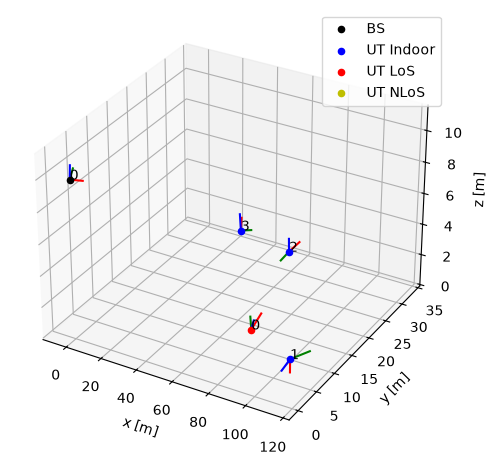

In [4]:
# Define the UT antenna array
ut_array = Antenna(polarization="single",
                   polarization_type="V",
                   antenna_pattern="omni",
                   carrier_frequency=carrier_frequency)

# Define the BS antenna array
bs_array = AntennaArray(num_rows=1,
                        num_cols=4,
                        polarization="dual",
                        polarization_type="VH",
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

# Create channel model
channel_model = UMi(carrier_frequency=carrier_frequency,
                    o2i_model="low",
                    ut_array=ut_array,
                    bs_array=bs_array,
                    direction=direction,
                    enable_pathloss=False,
                    enable_shadow_fading=False)

# Generate the topology
topology = gen_topology(batch_size, num_ut, scenario)

# Set the topology
channel_model.set_topology(*topology)

# Visualize the topology
channel_model.show_topology()

In [5]:
# The number of transmitted streams is equal to the number of UT antennas
num_streams_per_tx = 1

# Create an RX-TX association matrix
# rx_tx_association[i,j]=1 means that receiver i gets at least one stream
# from transmitter j. Depending on the transmission direction (uplink or downlink),
# the role of UT and BS can change. However, as we have only a single
# transmitter and receiver, this does not matter:
rx_tx_association = np.zeros([1, num_ut])
rx_tx_association[0, :] = 1

# Instantiate a StreamManagement object
# This determines which data streams are determined for which receiver.
# In this simple setup, this is fairly simple. However, it can get complicated
# for simulations with many transmitters and receivers.
sm = StreamManagement(rx_tx_association, num_streams_per_tx)

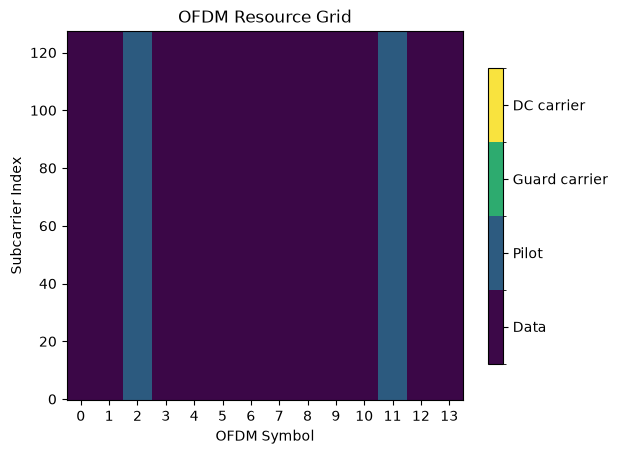

In [6]:
rg = ResourceGrid(num_ofdm_symbols=14,
                  fft_size=128,
                  subcarrier_spacing=30e3,
                  num_tx=num_ut,
                  num_streams_per_tx=num_streams_per_tx,
                  cyclic_prefix_length=20,
                  pilot_pattern="kronecker",
                  pilot_ofdm_symbol_indices=[2,11])
rg.show();

In [7]:
num_bits_per_symbol = 2 # QPSK modulation
coderate = 0.5 # The code rate
n = int(rg.num_data_symbols*num_bits_per_symbol) # Number of coded bits
k = int(n*coderate) # Number of information bits

# The binary source will create batches of information bits
binary_source = BinarySource()
qam_source = QAMSource(num_bits_per_symbol)

# The encoder maps information bits to coded bits
encoder = LDPC5GEncoder(k, n)

# The mapper maps blocks of information bits to constellation symbols
mapper = Mapper("qam", num_bits_per_symbol)

# The resource grid mapper maps symbols onto an OFDM resource grid
rg_mapper = ResourceGridMapper(rg)

# This function removes nulled subcarriers from any tensor having the shape of a resource grid
remove_nulled_scs = RemoveNulledSubcarriers(rg)

# The LS channel estimator will provide channel estimates and error variances
ls_est = LSChannelEstimator(rg, interpolation_type="nn")

# The LMMSE equalizer will provide soft symbols together with noise variance estimates
lmmse_equ = LMMSEEqualizer(rg, sm)

# The demapper produces LLR for all coded bits
demapper = Demapper("app", "qam", num_bits_per_symbol)

# The decoder provides hard-decisions on the information bits
decoder = LDPC5GDecoder(encoder, hard_out=True)

# OFDM CHannel
ofdm_channel = OFDMChannel(channel_model, rg, add_awgn=True, normalize_channel=False, return_channel=True)
channel_freq = ApplyOFDMChannel(add_awgn=True)
frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)

## Uplink Transmissions in the Frequency Domain

We now simulate a batch of uplink transmissions. We keep references to the estimated and actual channel frequency responses.

In [8]:
ebno_db = 10
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate, rg)
b = binary_source([batch_size, num_ut, rg.num_streams_per_tx, encoder.k])
c = encoder(b)
x = mapper(c)
x_rg = rg_mapper(x)

a, tau = channel_model(num_time_samples=rg.num_ofdm_symbols, sampling_frequency=1/rg.ofdm_symbol_duration)
h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)

y = channel_freq(x_rg, h_freq, no)
h_hat, err_var = ls_est (y, no)
x_hat, no_eff = lmmse_equ(y, h_hat, err_var, no)
llr = demapper(x_hat, no_eff)
b_hat = decoder(llr)
print("BER: {}".format(compute_ber(b, b_hat).cpu().numpy()))

BER: 0.0


### Compare Estimated and Actual Frequency Responses
We can now compare the estimated frequency responses and ground truth:

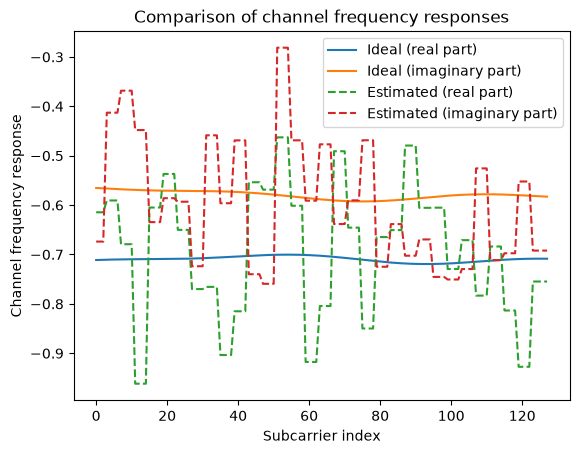

In [9]:
# In the example above, we assumed perfect CSI, i.e.,
# h_hat correpsond to the exact ideal channel frequency response.
h_perf = remove_nulled_scs(h_freq)[0,0,0,0,0,0]

# We now compute the LS channel estimate from the pilots.
h_est = h_hat[0,0,0,0,0,0]

plt.figure()
plt.plot(np.real(h_perf.cpu()))
plt.plot(np.imag(h_perf.cpu()))
plt.plot(np.real(h_est.cpu()), "--")
plt.plot(np.imag(h_est.cpu()), "--")
plt.xlabel("Subcarrier index")
plt.ylabel("Channel frequency response")
plt.legend(["Ideal (real part)", "Ideal (imaginary part)", "Estimated (real part)", "Estimated (imaginary part)"]);
plt.title("Comparison of channel frequency responses");

### Understand the Difference Between the Channel Models
Before we proceed with more advanced simulations, it is important to understand the differences
between the UMi, UMa, and RMa models. In the following code snippet, we compute the empirical cummulative
distribution function (CDF) of the condition number of the channel frequency response matrix
between all receiver and transmit antennas.

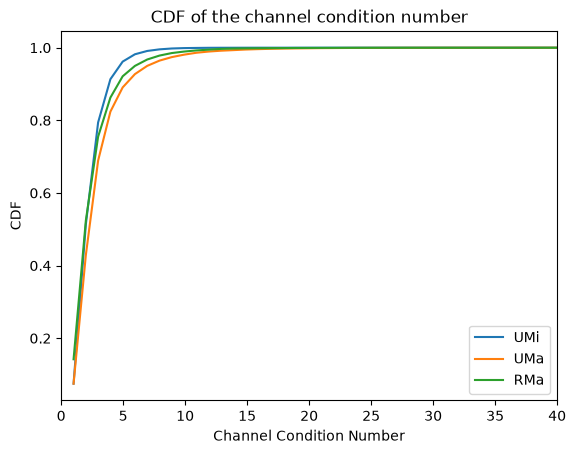

In [10]:
def cond_hist(scenario):
    """Generates a histogram of the channel condition numbers"""

    # Setup a CIR generator
    if scenario == "umi":
        channel_model = UMi(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "uma":
        channel_model = UMa(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "rma":
        channel_model = RMa(carrier_frequency=carrier_frequency,
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)

    topology = gen_topology(1024, num_ut, scenario)

    # Set the topology
    channel_model.set_topology(*topology)

    # Generate random CIR realizations
    # As we nned only a single sample in time, the sampling_frequency
    # does not matter.
    cir = channel_model(1, 1)

    # Compute the frequency response
    h = cir_to_ofdm_channel(frequencies, *cir, normalize=True)

    h = torch.squeeze(h)
    h = torch.permute(h, (0, 3, 1, 2))

    # Compute condition number
    c = np.reshape(np.linalg.cond(h.cpu().numpy()), [-1])

    # Compute normalized histogram
    hist, bins = np.histogram(c, 100, (1, 100))
    hist = hist/np.sum(hist)
    return bins[:-1], hist

plt.figure()
for cdl_model in ["umi", "uma", "rma"]:
    bins, hist = cond_hist(cdl_model)
    plt.plot(bins, np.cumsum(hist))
plt.xlim([0,40])
plt.legend(["UMi", "UMa", "RMa"]);
plt.xlabel("Channel Condition Number")
plt.ylabel("CDF")
plt.title("CDF of the channel condition number");

From the figure above, you can observe that the UMi and UMa models
are better conditioned than the RMa model. This makes
them more suitable for MIMO transmissions as we will observe in the next
section.

It is also interesting to look at the channel frequency responses of these different models, as done in the next cell:

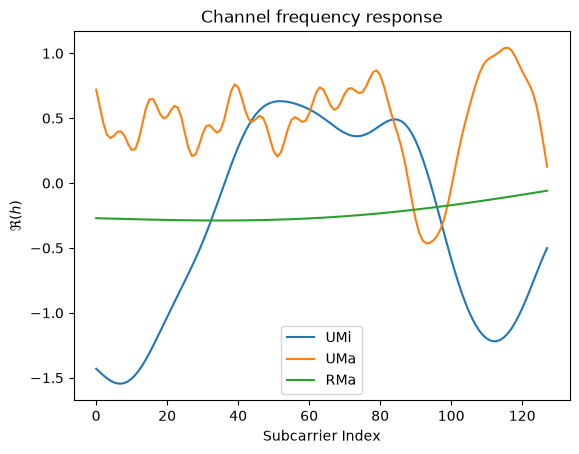

In [11]:
def freq_response(scenario):
    """Generates an example frequency response"""

    # Setup a CIR generator
    if scenario == "umi":
        channel_model = UMi(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "uma":
        channel_model = UMa(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "rma":
        channel_model = RMa(carrier_frequency=carrier_frequency,
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)

    topology = gen_topology(1, num_ut, scenario)

    # Set the topology
    channel_model.set_topology(*topology)

    # Generate random CIR realizations
    # As we nned only a single sample in time, the sampling_frequency
    # does not matter.
    cir = channel_model(1, 1)

    # Compute the frequency response
    h = cir_to_ofdm_channel(frequencies, *cir, normalize=True)
    h = h.squeeze()

    return h[0,0]

plt.figure()
for cdl_model in ["umi", "uma", "rma"]:
    h = freq_response(cdl_model)
    plt.plot(np.real(h.cpu()))
plt.legend(["UMi", "UMa", "RMa"]);
plt.xlabel("Subcarrier Index")
plt.ylabel(r"$\Re(h)$")
plt.title("Channel frequency response");

The RMa model has significantly less frequency selectivity than the other models which makes channel estimation easier.

### Setup a Sionna Block for BER simulations

In [12]:
class Model(Block):
    def __init__(self, scenario, perfect_csi=True, interpolation_type="nn", normalize_power=False):
        super().__init__()
        self._scenario = scenario
        self._perfect_csi = perfect_csi
        self._carrier_frequency = 3.5e9
        self._fft_size = 128
        self._subcarrier_spacing = 30e3
        self._num_ofdm_symbols = 14
        self._cyclic_prefix_length = 20
        self._pilot_ofdm_symbol_indices = [2, 11]
        self._num_bs_ant = 8
        self._num_ut = 4
        self._num_ut_ant = 1
        self._num_bits_per_symbol = 4
        self._coderate = 1.0
        self._lattice_n = 512

        self._lattice_engine = LatticeBasedEncryptor(n=self._lattice_n, verbose=False)

        bs_ut_association = np.zeros([1, self._num_ut])
        bs_ut_association[0, :] = 1
        self._rx_tx_association = bs_ut_association
        self._num_tx = self._num_ut
        self._num_streams_per_tx = self._num_ut_ant

        self._rg = ResourceGrid(num_ofdm_symbols=self._num_ofdm_symbols,
                                fft_size=self._fft_size,
                                subcarrier_spacing=self._subcarrier_spacing,
                                num_tx=self._num_tx,
                                num_streams_per_tx=self._num_streams_per_tx,
                                cyclic_prefix_length=self._cyclic_prefix_length,
                                pilot_pattern="kronecker",
                                pilot_ofdm_symbol_indices=self._pilot_ofdm_symbol_indices)

        self._sm = StreamManagement(self._rx_tx_association, self._num_streams_per_tx)

        self._ut_array = AntennaArray(num_rows=1, num_cols=1, polarization="single",
                                      polarization_type="V", antenna_pattern="omni",
                                      carrier_frequency=self._carrier_frequency)

        self._bs_array = AntennaArray(num_rows=1, num_cols=int(self._num_bs_ant/2),
                                      polarization="dual", polarization_type="cross",
                                      antenna_pattern="38.901", carrier_frequency=self._carrier_frequency)

        if self._scenario == "umi":
            self._channel_model = UMi(carrier_frequency=self._carrier_frequency, o2i_model="low",
                                      ut_array=self._ut_array, bs_array=self._bs_array,
                                      direction="uplink", enable_pathloss=False, enable_shadow_fading=False)
        elif self._scenario == "uma":
            self._channel_model = UMa(carrier_frequency=self._carrier_frequency, o2i_model="low",
                                      ut_array=self._ut_array, bs_array=self._bs_array,
                                      direction="uplink", enable_pathloss=False, enable_shadow_fading=False)
        elif self._scenario == "rma":
            self._channel_model = RMa(carrier_frequency=self._carrier_frequency, ut_array=self._ut_array,
                                      bs_array=self._bs_array, direction="uplink",
                                      enable_pathloss=False, enable_shadow_fading=False)

        self._binary_source = BinarySource()
        self._k = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        self._mapper = Mapper("qam", self._num_bits_per_symbol, dtype=torch.complex128)
        self._rg_mapper = ResourceGridMapper(self._rg, dtype=torch.complex128)

        self._ofdm_channel = OFDMChannel(self._channel_model, self._rg, add_awgn=True,
                                         normalize_channel=True, return_channel=True, dtype=torch.complex128)
        self._remove_nulled_subcarriers = RemoveNulledSubcarriers(self._rg, dtype=torch.complex128)
        self._ls_est = LSChannelEstimator(self._rg, interpolation_type=interpolation_type, dtype=torch.complex128)
        # ZF, not LMMSE: Sionna's LMMSE assumes unit-power symbols; the GGH ciphertext is ~1e12x larger,
        # and the leftover inter-user interference breaks Babai decoding.
        # The attribute name is kept so the rest of the code is unchanged.
        self._lmmse_equ = ZFEqualizer(self._rg, self._sm, dtype=torch.complex128)
        self._demapper = Demapper("app", "qam", self._num_bits_per_symbol, dtype=torch.float64)

        # Optional power normalisation (true-SNR axis): transmit C/sqrt(P), receiver multiplies by sqrt(P).
        # P is a fixed public constant per key, measured once on random data.
        self._normalize_power = normalize_power
        self._tx_scale = 1.0
        if normalize_power:
            s = self._mapper(self._binary_source([64, self._lattice_n * self._num_bits_per_symbol]))
            self._lattice_engine.B = self._lattice_engine.B.to(device=s.device, dtype=torch.complex128)
            c = self._lattice_engine.encrypt(s.to(torch.complex128) * 10**0.5) / 10**0.5
            self._tx_scale = float(torch.sqrt(torch.mean(torch.abs(c) ** 2)))

    def babai_decode_internal(self, x_hat_reshaped):
        device = x_hat_reshaped.device
        x_input = x_hat_reshaped.to(dtype=torch.complex128)
        R = self._lattice_engine.R.to(device=device, dtype=torch.complex128)
        R_inv = torch.linalg.pinv(R)
        B_inv = self._lattice_engine.B_inv.to(device=device, dtype=torch.complex128)

        Y = torch.matmul(x_input, R_inv.T)
        Y_integer = torch.round(Y.real) + 1j * torch.round(Y.imag)

        lattice_point = torch.matmul(Y_integer, R.T)
        S_hat = torch.matmul(lattice_point, B_inv.T)
        return S_hat

    def new_topology(self, batch_size):
        self._channel_model.reset_topology()
        topology = gen_topology(batch_size, self._num_ut, self._scenario, min_ut_velocity=0.0, max_ut_velocity=0.0)
        self._channel_model.set_topology(*topology)

    def call(self, batch_size, ebno_db):
        self.new_topology(batch_size)
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)
        b = self._binary_source([batch_size, self._num_tx, self._num_streams_per_tx, self._k])

        x = self._mapper(b)
        x_shape = x.shape
        x_reshaped = torch.reshape(x, (-1, self._lattice_n))
        self._lattice_engine.B = self._lattice_engine.B.to(device=x.device, dtype=torch.complex128)
        qs = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x.device))
        x_enc_blocks = self._lattice_engine.encrypt(x_reshaped.to(torch.complex128) * qs) / qs
        x_enc = torch.reshape(x_enc_blocks, x_shape) / self._tx_scale

        x_rg = self._rg_mapper(x_enc)
        y, h = self._ofdm_channel(x_rg, no)

        if self._perfect_csi:
            h_hat = self._remove_nulled_subcarriers(h)
            err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        else:
            h_hat, err_var = self._ls_est(y, no)

        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        qam_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x_hat.device))
        x_hat_lattice_domain = x_hat * qam_scale * self._tx_scale

        x_hat_shape = x_hat.shape
        x_hat_reshaped = torch.reshape(x_hat_lattice_domain, (-1, self._lattice_n))
        x_dec_lattice_blocks = self.babai_decode_internal(x_hat_reshaped)
        x_dec_lattice = torch.reshape(x_dec_lattice_blocks, x_hat_shape)

        x_dec = qam16_lattice_to_normalized(x_dec_lattice)
        llr = self._demapper(x_dec.to(torch.complex128), no_eff.to(torch.float64))
        b_hat = torch.where(llr > 0, torch.tensor(1.0, dtype=torch.float64, device=llr.device), torch.tensor(0.0, dtype=torch.float64, device=llr.device))

        return b, b_hat

In [13]:
class InterpolationModel(Model):
    def __init__(self, scenario, perfect_csi=True, interpolation_type="nn", normalize_power=False):
        super().__init__(scenario, perfect_csi, interpolation_type, normalize_power)
        # Further increase pilot density to ensure Bob can decrypt
        # Using 7 pilots across 14 symbols [0, 2, 4, 6, 8, 10, 12]
        self._pilot_ofdm_symbol_indices = [0, 2, 4, 6, 8, 10, 12]

        # Re-initialize resource grid
        self._rg = ResourceGrid(num_ofdm_symbols=self._num_ofdm_symbols,
                                fft_size=self._fft_size,
                                subcarrier_spacing=self._subcarrier_spacing,
                                num_tx=self._num_tx,
                                num_streams_per_tx=self._num_streams_per_tx,
                                cyclic_prefix_length=self._cyclic_prefix_length,
                                pilot_pattern="kronecker",
                                pilot_ofdm_symbol_indices=self._pilot_ofdm_symbol_indices)

        # Recalculate k for the significantly reduced data capacity
        self._k = int(self._rg.num_data_symbols * self._num_bits_per_symbol)

        self._ls_est = LSChannelEstimator(self._rg, interpolation_type=interpolation_type, dtype=torch.complex128)
        self._rg_mapper = ResourceGridMapper(self._rg, dtype=torch.complex128)
        self._ofdm_channel = OFDMChannel(self._channel_model, self._rg, add_awgn=True,
                                         normalize_channel=True, return_channel=True, dtype=torch.complex128)
        self._remove_nulled_subcarriers = RemoveNulledSubcarriers(self._rg, dtype=torch.complex128)
        self._lmmse_equ = ZFEqualizer(self._rg, self._sm, dtype=torch.complex128)   # see Model

### True-SNR axis for all GGH sweeps below

Earlier versions sent the ciphertext **without** power normalisation. A GGH ciphertext is about 10¹² times stronger than a unit-power 16-QAM symbol, while the noise level is set for unit power. So "60 dB" on those plots is really about 180 dB.

Here the transmitter divides the ciphertext by a fixed, public scale √P, so the transmit power is 1, and the receiver multiplies by √P. Now the Eb/N0 axis is the **true** Eb/N0. The equalizer is ZF: Sionna's LMMSE assumes unit-power symbols and leaves inter-user interference that breaks Babai decoding.


With `TRUE_SNR = True` every GGH model below normalises its power, so the Eb/N0 axis is the true one. Expect the GGH waterfall at about **100–120 dB** (this is the result, not a bug). Set `TRUE_SNR = False` to reproduce the old labelled axis. With ZF and double precision, Bob then decodes from about 0 dB labelled, because the ciphertext power (+110–125 dB) is hidden in the label.

In [14]:
TRUE_SNR = True   # normalise GGH transmit power -> the Eb/N0 axis is the true Eb/N0
GGH_EBNO_DB = list(np.arange(80, 151, 10.0)) if TRUE_SNR else list(np.arange(0, 81, 10.0))
AXIS = r"true $E_b/N_0$ (dB)" if TRUE_SNR else r"$E_b/N_0$ (dB), ciphertext power not included"


Simulating with NN interpolation...
  Simulating scenario: UMI for NN interpolation...
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     80.0 | 4.9926e-01 | 1.0000e+00 |      458076 |      917504 |          256 |         256 |         1.3 |reached target block errors
     90.0 | 5.0005e-01 | 1.0000e+00 |      458800 |      917504 |          256 |         256 |         1.2 |reached target block errors
    100.0 | 5.0018e-01 | 1.0000e+00 |      458915 |      917504 |          256 |         256 |         1.2 |reached target block errors
    110.0 | 4.9930e-01 | 1.0000e+00 |      458112 |      917504 |          256 |         256 |         1.3 |reached target block errors
    120.0 | 4.9958e-01 | 1.0000e+00 |      458365 |      917504 |          256 |         256 |         1.2 |reach

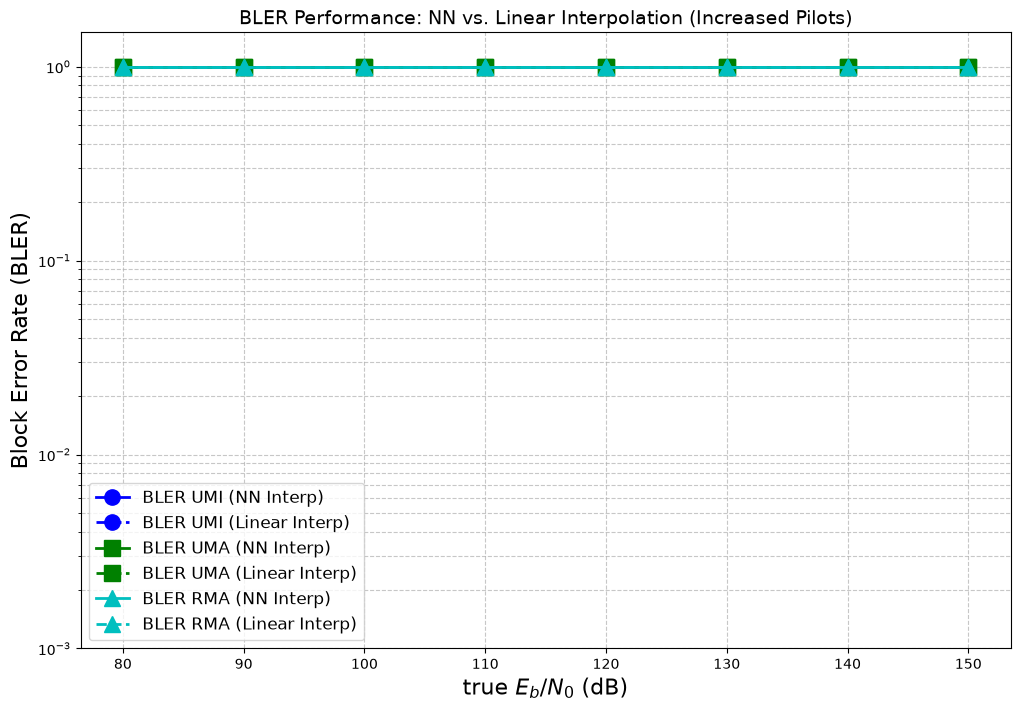

In [15]:
# Simulation parameters for interpolation comparison
SIMS_INTERP = {
    "ebno_db": np.array(GGH_EBNO_DB),
    "scenario": ["umi", "uma", "rma"],
    "interpolation_type": ["nn", "lin"],
    "results": {
        "nn": {"bler": {}, "ber": {}},
        "lin": {"bler": {}, "ber": {}}
    },
    "batch_size": 64
}

start_interp = time.time()

for interp_type in SIMS_INTERP["interpolation_type"]:
    print(f"\nSimulating with {interp_type.upper()} interpolation...")
    for scenario in SIMS_INTERP["scenario"]:
        print(f"  Simulating scenario: {scenario.upper()} for {interp_type.upper()} interpolation...")
        # Using InterpolationModel which handles the updated pilot density and k-value
        model = InterpolationModel(scenario=scenario, perfect_csi=False, interpolation_type=interp_type, normalize_power=TRUE_SNR)
        if torch.cuda.is_available():
            model.cuda()
        model._channel_model.allocate_topology_tensors(batch_size=SIMS_INTERP["batch_size"], num_bs=1, num_ut=model._num_ut)

        ber, bler = sim_ber(model,
                            SIMS_INTERP["ebno_db"],
                            batch_size=SIMS_INTERP["batch_size"],
                            max_mc_iter=50,
                            num_target_block_errors=50,
                            target_bler=1e-3,
                            compile_mode=None
                           )

        SIMS_INTERP["results"][interp_type][scenario] = {"bler": bler.cpu().numpy(), "ber": ber.cpu().numpy()}

SIMS_INTERP["duration"] = time.time() - start_interp
print(f"\nTotal interpolation comparison simulation time: {SIMS_INTERP['duration']:.2f} seconds")

plt.figure(figsize=(12, 8))
colors = {'umi': 'b', 'uma': 'g', 'rma': 'c'}
markers = {'umi': 'o', 'uma': 's', 'rma': '^'}

for scenario in SIMS_INTERP["scenario"]:
    plt.semilogy(SIMS_INTERP["ebno_db"], SIMS_INTERP["results"]["nn"][scenario]["bler"],
                 color=colors[scenario], marker=markers[scenario], markersize=11, linewidth=2,
                 linestyle='-', label=f"BLER {scenario.upper()} (NN Interp)")
    plt.semilogy(SIMS_INTERP["ebno_db"], SIMS_INTERP["results"]["lin"][scenario]["bler"],
                 color=colors[scenario], marker=markers[scenario], markersize=11, linewidth=2,
                 linestyle='--', label=f"BLER {scenario.upper()} (Linear Interp)")

plt.xlabel(AXIS, fontsize=16)
plt.ylabel("Block Error Rate (BLER)", fontsize=16)
plt.title("BLER Performance: NN vs. Linear Interpolation (Increased Pilots)", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=12)
plt.ylim([1e-3, 1.5])
plt.show()

If you do not want to run the simulations (which can take quite some time) yourself, you can skip the next cell and simply look at the results in the next cell.

In [16]:
# Full scenario simulation: UMi, UMa, RMa (0-80 dB)
SIMS = {
    "ebno_db" : GGH_EBNO_DB,
    "scenario" : ["umi", "uma", "rma"],
    "perfect_csi" : [True],
    "ber" : [],
    "bler" : [],
    "duration" : None,
    "batch_size" : 64
}

start = time.time()

for scenario in SIMS["scenario"]:
    for perfect_csi in SIMS["perfect_csi"]:
        print(f"Simulating scenario: {scenario}...")
        model = Model(scenario=scenario, perfect_csi=perfect_csi, normalize_power=TRUE_SNR)
        if torch.cuda.is_available():
            model.cuda()
        model._channel_model.allocate_topology_tensors(batch_size=SIMS["batch_size"], num_bs=1, num_ut=model._num_ut)

        ber, bler = sim_ber(model,
                            SIMS["ebno_db"],
                            batch_size=SIMS["batch_size"],
                            max_mc_iter=50,
                            num_target_block_errors=50,
                            target_bler=1e-3,
                            compile_mode=None
                            )

        SIMS["ber"].append(list(ber.cpu().numpy()))
        SIMS["bler"].append(list(bler.cpu().numpy()))

SIMS["duration"] = time.time() - start
print(f"Total simulation time: {SIMS['duration']:.2f} seconds")

Simulating scenario: umi...
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     80.0 | 4.9973e-01 | 1.0000e+00 |      786014 |     1572864 |          256 |         256 |         1.2 |reached target block errors
     90.0 | 4.9932e-01 | 1.0000e+00 |      785363 |     1572864 |          256 |         256 |         1.2 |reached target block errors
    100.0 | 2.3899e-01 | 9.4922e-01 |      375898 |     1572864 |          243 |         256 |         1.2 |reached target block errors
    110.0 | 1.2199e-03 | 1.3951e-02 |       26863 |    22020096 |           50 |        3584 |        16.8 |reached target block errors
    120.0 | 0.0000e+00 | 0.0000e+00 |           0 |    78643200 |            0 |       12800 |        59.9 |reached max iterations

Simulation stopped as no error occurred @

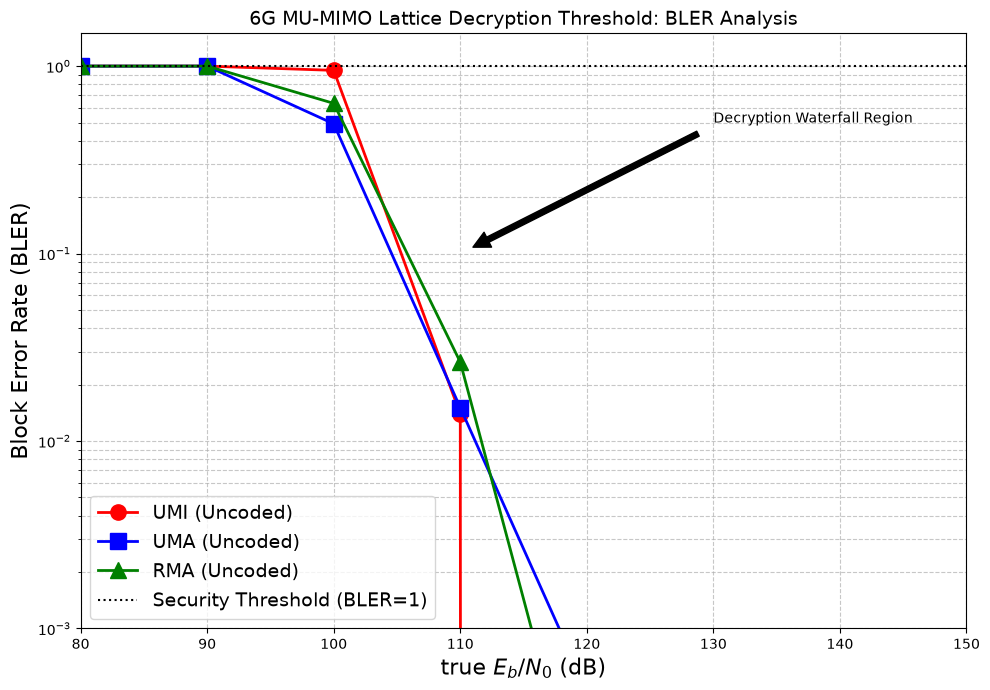

In [17]:
plt.figure(figsize=(10, 7))

colors = {'umi': 'r', 'uma': 'b', 'rma': 'g'}
markers = {'umi': 'o', 'uma': 's', 'rma': '^'}

for i, scenario in enumerate(SIMS["scenario"]):
    # Plot BLER as the primary metric for 6G security validation
    plt.semilogy(SIMS["ebno_db"], SIMS["bler"][i],
                 color=colors[scenario], marker=markers[scenario],
                 markersize=11, linewidth=2,
                 linestyle='-', label=f"{scenario.upper()} (Uncoded)")

plt.xlabel(AXIS, fontsize=16)
plt.ylabel("Block Error Rate (BLER)", fontsize=16)
plt.title("6G MU-MIMO Lattice Decryption Threshold: BLER Analysis", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.axhline(y=1.0, color='k', linestyle=':', label='Security Threshold (BLER=1)')
plt.legend(loc='lower left', fontsize=14)
plt.ylim([1e-3, 1.5])
plt.xlim([GGH_EBNO_DB[0], GGH_EBNO_DB[-1]])

# Adding annotations for the decryption 'waterfall' region
plt.annotate('Decryption Waterfall Region',
             xy=(GGH_EBNO_DB[3], 0.1), xytext=(GGH_EBNO_DB[5], 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

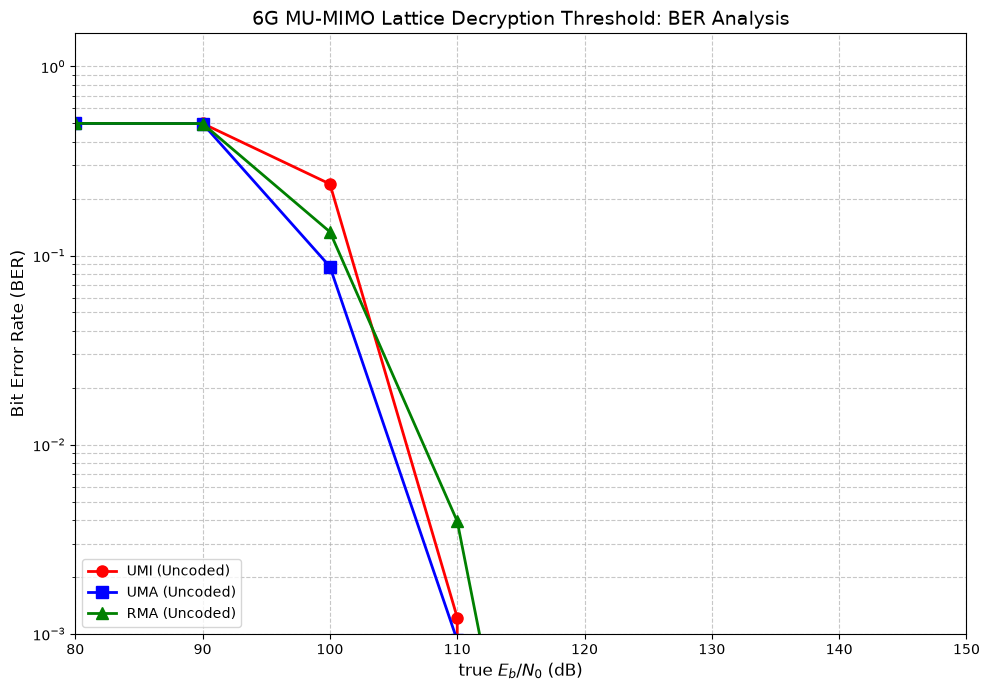

In [18]:
plt.figure(figsize=(10, 7))

for i, scenario in enumerate(SIMS["scenario"]):
    plt.semilogy(SIMS["ebno_db"], SIMS["ber"][i],
                 color=colors[scenario], marker=markers[scenario],
                 markersize=8, linewidth=2,
                 linestyle='-', label=f"{scenario.upper()} (Uncoded)")

plt.xlabel(AXIS, fontsize=12)
plt.ylabel("Bit Error Rate (BER)", fontsize=12)
plt.title("6G MU-MIMO Lattice Decryption Threshold: BER Analysis", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=10)
plt.ylim([1e-3, 1.5])
plt.xlim([GGH_EBNO_DB[0], GGH_EBNO_DB[-1]])
plt.tight_layout()
plt.show()

Due to the worse channel conditioning, the RMa model achieves the worst performance with perfect CSI. However, as a result of the smaller frequency selectivity, imperfect channel estimation only leads to an almost constant 6dB performace loss. For the UMI and UMa models, the used channel estimator with nearest-neighbor interpolation is not accurate enough so that the BER curves saturate at high SNR. This could, for example, be circumvented with another interpolation method (e.g., [linear interpolation with time averaging](https://nvlabs.github.io/sionna/phy/api/ofdm/sionna.phy.ofdm.LinearInterpolator.html)) or a different pilot pattern.

Simulating for scenario: UMI...
Simulating Bob's performance for UMI...
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     80.0 | 4.9986e-01 | 1.0000e+00 |      786219 |     1572864 |          256 |         256 |         1.2 |reached target block errors
     90.0 | 4.9906e-01 | 1.0000e+00 |      784960 |     1572864 |          256 |         256 |         1.2 |reached target block errors
    100.0 | 1.3944e-01 | 8.2031e-01 |      219316 |     1572864 |          210 |         256 |         1.2 |reached target block errors
    110.0 | 3.3250e-04 | 5.2426e-03 |       19873 |    59768832 |           51 |        9728 |        46.6 |reached target block errors
    120.0 | 0.0000e+00 | 0.0000e+00 |           0 |    78643200 |            0 |       12800 |        61.3 |reached max iteration

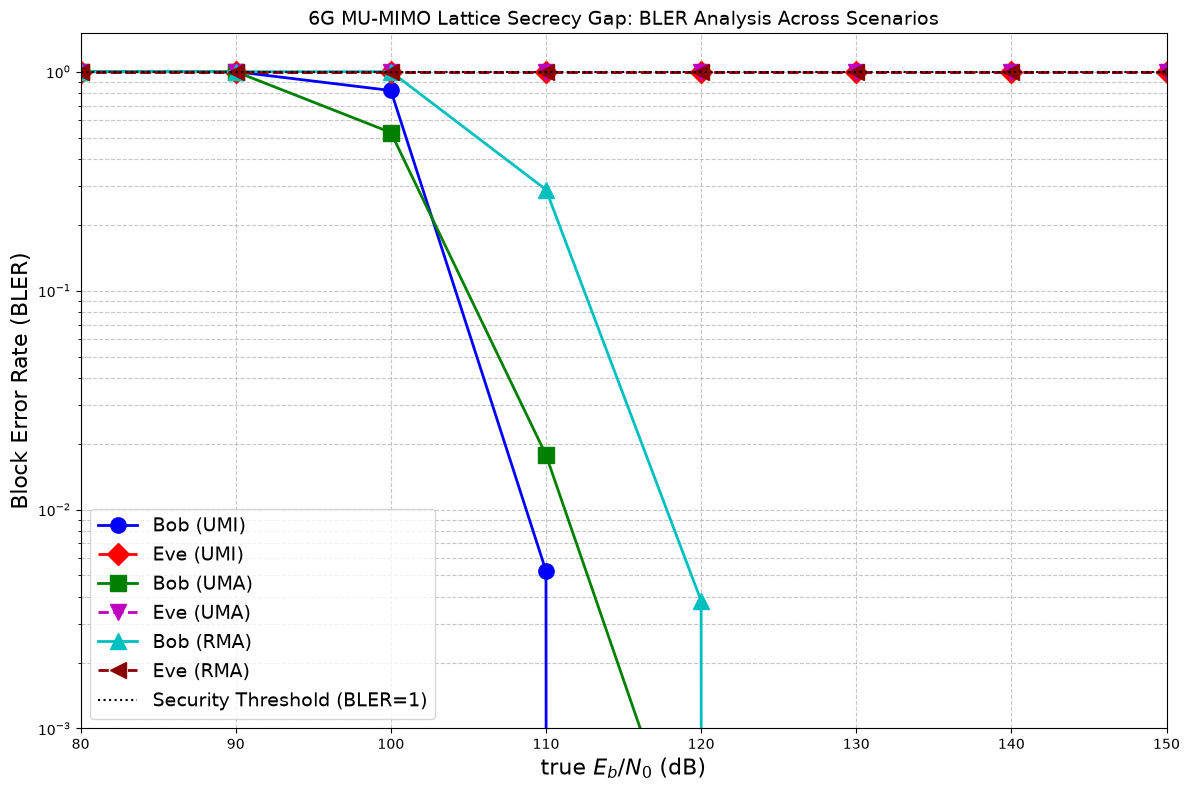

In [19]:
all_bob_blers = {}
all_eve_blers = {}
all_bob_bers = {}
all_eve_bers = {}

ebno_db_range = np.array(SIMS["ebno_db"])

for current_scenario in SIMS["scenario"]:
    print(f"Simulating for scenario: {current_scenario.upper()}...")
    bob_model = Model(scenario=current_scenario, perfect_csi=True, normalize_power=TRUE_SNR)
    eve_model = Model(scenario=current_scenario, perfect_csi=True, normalize_power=TRUE_SNR)

    if torch.cuda.is_available():
        bob_model.cuda()
        eve_model.cuda()

    bob_model._channel_model.allocate_topology_tensors(batch_size=SIMS["batch_size"], num_bs=1, num_ut=bob_model._num_ut)
    eve_model._channel_model.allocate_topology_tensors(batch_size=SIMS["batch_size"], num_bs=1, num_ut=eve_model._num_ut)

    eve_model._lattice_engine.R = eve_model._lattice_engine.B.to(dtype=torch.complex128)

    print(f"Simulating Bob's performance for {current_scenario.upper()}...")
    bob_ber, bob_bler = sim_ber(bob_model,
                                ebno_db_range,
                                batch_size=SIMS["batch_size"],
                                max_mc_iter=50,
                                num_target_block_errors=50,
                                target_bler=1e-3,
                                compile_mode=None
                                )
    all_bob_blers[current_scenario] = bob_bler
    all_bob_bers[current_scenario] = bob_ber

    print(f"Simulating Eve's performance for {current_scenario.upper()}...")
    eve_ber, eve_bler = sim_ber(eve_model,
                                ebno_db_range,
                                batch_size=SIMS["batch_size"],
                                max_mc_iter=50,
                                num_target_block_errors=50,
                                target_bler=1e-3,
                                compile_mode=None
                                )
    all_eve_blers[current_scenario] = eve_bler
    all_eve_bers[current_scenario] = eve_ber

plt.figure(figsize=(12, 8))

colors_bob = {'umi': 'b', 'uma': 'g', 'rma': 'c'}
markers_bob = {'umi': 'o', 'uma': 's', 'rma': '^'}

colors_eve = {'umi': 'r', 'uma': 'm', 'rma': 'darkred'}
markers_eve = {'umi': 'D', 'uma': 'v', 'rma': '<'}

for current_scenario in SIMS["scenario"]:
    plt.semilogy(ebno_db_range, all_bob_blers[current_scenario].cpu().numpy(),
                 color=colors_bob[current_scenario], marker=markers_bob[current_scenario], markersize=11, linewidth=2,
                 linestyle='-', label=f"Bob ({current_scenario.upper()})")

    plt.semilogy(ebno_db_range, all_eve_blers[current_scenario].cpu().numpy(),
                 color=colors_eve[current_scenario], marker=markers_eve[current_scenario], markersize=11, linewidth=2,
                 linestyle='--', label=f"Eve ({current_scenario.upper()})")

plt.xlabel(AXIS, fontsize=16)
plt.ylabel("Block Error Rate (BLER)", fontsize=16)
plt.title("6G MU-MIMO Lattice Secrecy Gap: BLER Analysis Across Scenarios", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.axhline(y=1.0, color='k', linestyle=':', label='Security Threshold (BLER=1)')
plt.legend(loc='lower left', fontsize=14)
plt.ylim([1e-3, 1.5])
plt.xlim([GGH_EBNO_DB[0], GGH_EBNO_DB[-1]])
plt.tight_layout()
plt.show()

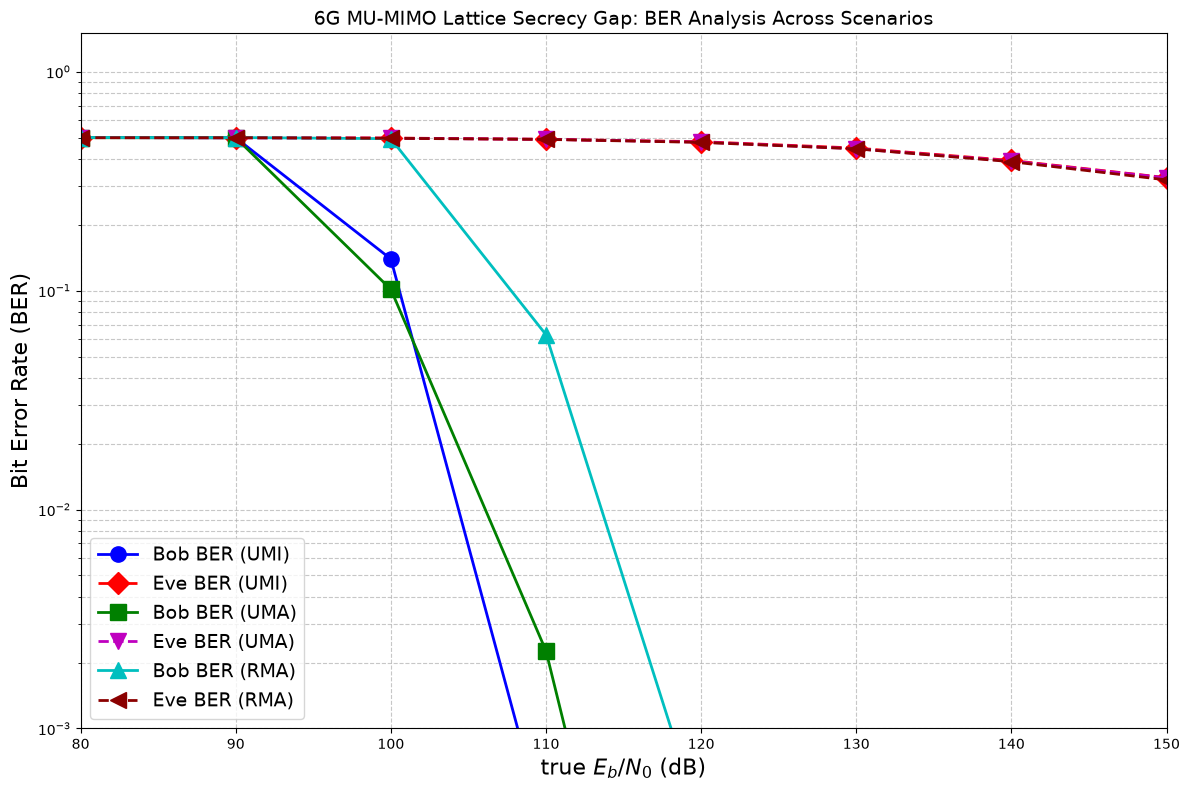

In [20]:
plt.figure(figsize=(12, 8))

# Re-using defined colors and markers for consistency or defining new ones if needed
colors_bob = {'umi': 'b', 'uma': 'g', 'rma': 'c'}
markers_bob = {'umi': 'o', 'uma': 's', 'rma': '^'}

colors_eve = {'umi': 'r', 'uma': 'm', 'rma': 'darkred'}
markers_eve = {'umi': 'D', 'uma': 'v', 'rma': '<'}

for current_scenario in SIMS["scenario"]:
    # Plot Bob's BER curve
    plt.semilogy(ebno_db_range, all_bob_bers[current_scenario].cpu().numpy(),
                 color=colors_bob[current_scenario], marker=markers_bob[current_scenario], markersize=11, linewidth=2,
                 linestyle='-', label=f"Bob BER ({current_scenario.upper()})")

    # Plot Eve's BER curve
    plt.semilogy(ebno_db_range, all_eve_bers[current_scenario].cpu().numpy(),
                 color=colors_eve[current_scenario], marker=markers_eve[current_scenario], markersize=11, linewidth=2,
                 linestyle='--', label=f"Eve BER ({current_scenario.upper()})")

plt.xlabel(AXIS, fontsize=16)
plt.ylabel("Bit Error Rate (BER)", fontsize=16)
plt.title("6G MU-MIMO Lattice Secrecy Gap: BER Analysis Across Scenarios", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=14)
plt.ylim([1e-3, 1.5])
plt.xlim([GGH_EBNO_DB[0], GGH_EBNO_DB[-1]])
plt.tight_layout()
plt.show()

In [21]:
from PIL import Image
import numpy as np
from scipy.datasets import face

# Prepare built-in test image to avoid download dependency issues
img_data = face(gray=True)
img = Image.fromarray(img_data)
import os
image_path = "/content/test_image.png" if os.path.isdir("/content") else "test_image.png"
img.save(image_path)
print(f"Built-in test image prepared and saved to {image_path}")

Built-in test image prepared and saved to /content/test_image.png


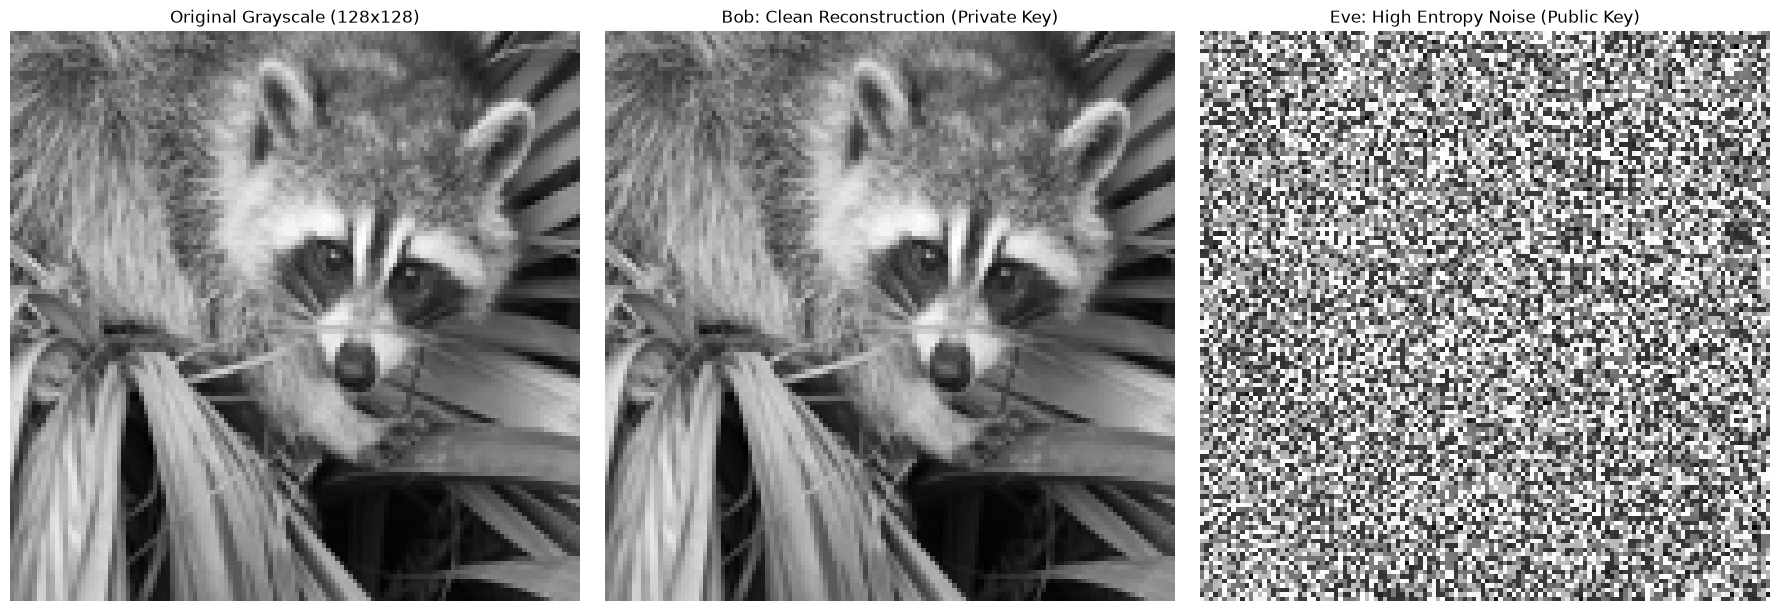

In [22]:
# Import necessary libraries for image processing
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

# Optimized ImageModel for single-batch high-fidelity reconstruction
class HighFidelityImageModel(Model):
    def call_with_static_channel(self, b_input, ebno_db, h_freq_static):
        # Single large batch processing to ensure perfect synchronization
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)

        # Lattice Encryption
        x = self._mapper(b_input)
        x_shape = x.shape
        x_reshaped = torch.reshape(x, (-1, self._lattice_n))
        self._lattice_engine.B = self._lattice_engine.B.to(device=x.device, dtype=torch.complex128)
        qs = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x.device))
        x_enc_blocks = self._lattice_engine.encrypt(x_reshaped.to(torch.complex128) * qs) / qs
        x_enc = torch.reshape(x_enc_blocks, x_shape) / self._tx_scale

        # OFDM Transmission with static channel
        x_rg = self._rg_mapper(x_enc)
        y = ApplyOFDMChannel(add_awgn=True)(x_rg, h_freq_static, no)

        # Perfect CSI Receiver
        h_hat = self._remove_nulled_subcarriers(h_freq_static)
        err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        # Scale and Babai Decrypt
        qam_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x_hat.device))
        x_hat_lattice = x_hat * qam_scale * self._tx_scale
        x_dec_lattice = torch.reshape(self.babai_decode_internal(torch.reshape(x_hat_lattice, (-1, self._lattice_n))), x_hat.shape)

        # Demapping
        x_dec = qam16_lattice_to_normalized(x_dec_lattice)
        llr = self._demapper(x_dec.to(torch.complex128), no_eff.to(torch.float64))
        b_hat = torch.where(llr > 0, torch.tensor(1.0, dtype=torch.float64, device=llr.device), torch.tensor(0.0, dtype=torch.float64, device=llr.device))
        return b_hat

# Using the prepared test_image.png for clean visual demonstration (image_path set in the previous cell)
img_original = Image.open(image_path)
res = 128
img_resized = img_original.convert("L").resize((res, res))
img_bits = np.unpackbits(np.array(img_resized).flatten()).astype(np.float64)
num_pixels = res * res

# Setup models
bob_model = HighFidelityImageModel(scenario="umi", perfect_csi=True, normalize_power=TRUE_SNR)
eve_model = HighFidelityImageModel(scenario="umi", perfect_csi=True, normalize_power=TRUE_SNR)
if torch.cuda.is_available():
    bob_model.cuda(); eve_model.cuda()

# Configure Eve with public basis (demonstrates Secrecy Gap)
eve_model._lattice_engine.R = eve_model._lattice_engine.B.to(dtype=torch.complex128)

# Single-batch configuration
bits_per_symbol_group = bob_model._num_ut * bob_model._k
num_full_symbols = int(np.ceil(len(img_bits) / bits_per_symbol_group))
padding = (num_full_symbols * bits_per_symbol_group) - len(img_bits)
img_bits_padded = np.pad(img_bits, (0, padding), "constant")
b_input = torch.tensor(img_bits_padded, dtype=torch.float64).reshape(num_full_symbols, bob_model._num_ut, 1, bob_model._k)
if torch.cuda.is_available(): b_input = b_input.cuda()

# Consistent Static Channel
topology = gen_topology(num_full_symbols, bob_model._num_ut, "umi", min_ut_velocity=0.0, max_ut_velocity=0.0)
bob_model._channel_model.set_topology(*topology)
a, tau = bob_model._channel_model(num_time_samples=bob_model._rg.num_ofdm_symbols, sampling_frequency=1/bob_model._rg.ofdm_symbol_duration)
h_static = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)

# Simulate transmission at high SNR
snr = 120.0 if TRUE_SNR else 60.0
with torch.no_grad():
    bob_b_hat = bob_model.call_with_static_channel(b_input, snr, h_static)
    eve_b_hat = eve_model.call_with_static_channel(b_input, snr, h_static)

# Final Clean Reconstruction (Cropping padding)
bob_final_bits = bob_b_hat.flatten().cpu().numpy().astype(np.uint8)[:num_pixels * 8]
eve_final_bits = eve_b_hat.flatten().cpu().numpy().astype(np.uint8)[:num_pixels * 8]

bob_res = np.packbits(bob_final_bits).reshape((res, res))
eve_res = np.packbits(eve_final_bits).reshape((res, res))

# Side-by-Side Comparison
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(img_resized, cmap="gray"); plt.title("Original Grayscale (128x128)"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(bob_res, cmap="gray"); plt.title("Bob: Clean Reconstruction (Private Key)"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(eve_res, cmap="gray"); plt.title("Eve: High Entropy Noise (Public Key)"); plt.axis("off")
plt.tight_layout()
plt.show()

## Sub-band Lattice Encryption

**Idea.** In the model above, each lattice block holds 512 symbols = 4 OFDM symbols × all 128 subcarriers. One faded subcarrier can make Babai decoding fail for the whole block.

Here we build each block from a **tile**: a narrow group of subcarriers (width `w`) taken over several OFDM symbols (length `T`). The lattice size is `n = w × T`.

- A narrow tile sits inside one coherence band, so the channel over the tile is nearly flat.
- The users here do not move (`max_ut_velocity = 0`), so the channel does not change in time. This lets a tile run over all 12 data symbols. We keep a large lattice (good for security) while staying narrow in frequency (good for reliability).
- Example: `w = 32, T = 12` gives `n = 384`, above the 350 that the GGH security analysis asks for.

**Fair test.** `128 × 3` (full-band) and `32 × 12` (sub-band) have the **same** lattice size, 384. Only the shape changes.

**Built-in check.** `w = 128, T = 4` with one shared basis is exactly the original `Model` (n = 512). Its curve should match the earlier results.

In [23]:
# ---------- Tile layout: which resource elements go into each lattice block ----------
def build_tile_perm(rg, band_width, band_time):
    """Return (perm, inv_perm, n_sub, num_tiles).
    perm reorders the data symbols (Sionna order) so that each consecutive group of
    n_sub = band_width * band_time symbols is one tile (w subcarriers x T data symbols)."""
    mask = rg.pilot_pattern.mask
    mask = mask.cpu().numpy() if hasattr(mask, "cpu") else np.asarray(mask)
    mask = mask[0, 0]                                   # [num_ofdm_symbols, num_subcarriers]
    coords = np.argwhere(mask == 0)                     # data REs, row-major = Sionna data order
    assert len(coords) == rg.num_data_symbols, "data layout check failed"

    sym_ids = np.unique(coords[:, 0])
    t_rank = np.searchsorted(sym_ids, coords[:, 0])     # 0..(num data symbols - 1)
    sc = coords[:, 1]
    n_sym, n_sc = len(sym_ids), int(sc.max()) + 1
    assert n_sc % band_width == 0, f"band_width must divide {n_sc}"
    assert n_sym % band_time == 0, f"band_time must divide {n_sym}"

    tile_id = (t_rank // band_time) * (n_sc // band_width) + (sc // band_width)
    perm = np.argsort(tile_id, kind="stable")           # group REs tile by tile
    inv_perm = np.argsort(perm)
    n_sub = band_width * band_time
    return perm, inv_perm, n_sub, len(perm) // n_sub


def babai_decode_with(engine, x, use_public_basis=False):
    """Babai round-off for one tile. use_public_basis=True simulates Eve (only has B)."""
    dev = x.device
    x = x.to(torch.complex128)
    R = (engine.B if use_public_basis else engine.R).to(device=dev, dtype=torch.complex128)
    R_inv = torch.linalg.pinv(R)
    B_inv = engine.B_inv.to(device=dev, dtype=torch.complex128)
    Y = torch.matmul(x, R_inv.T)
    Y_int = torch.round(Y.real) + 1j * torch.round(Y.imag)
    return torch.matmul(torch.matmul(Y_int, R.T), B_inv.T)

In [24]:
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder

class SubbandModel(Model):
    """Same system as Model, but GGH blocks are built from sub-band tiles.

    band_width      : subcarriers per tile (must divide 128)
    band_time       : data OFDM symbols per tile (must divide 12)
    distinct_bases  : True -> each tile has its own key pair (recommended for small tiles)
    use_ldpc        : outer 5G LDPC code (+ random interleaver) around the GGH layer
    coderate        : LDPC code rate
    normalize_power : scale ciphertext to unit power (fair across different n)
    eve             : decode with the public basis B (eavesdropper)
    """
    def __init__(self, scenario, band_width=32, band_time=12, distinct_bases=True,
                 use_ldpc=False, coderate=0.5, normalize_power=False, eve=False,
                 perfect_csi=True, llr_mag=3.0, seed=0):
        super().__init__(scenario, perfect_csi=perfect_csi)
        self._perm, self._inv_perm, self._n_sub, self._num_tiles = \
            build_tile_perm(self._rg, band_width, band_time)
        self._perm_t = torch.tensor(self._perm)
        self._inv_perm_t = torch.tensor(self._inv_perm)
        self._eve = eve
        self._normalize_power = normalize_power
        self._llr_mag = llr_mag

        # Keys: one engine per tile, or one shared engine
        n_engines = self._num_tiles if distinct_bases else 1
        self._engines = [LatticeBasedEncryptor(n=self._n_sub, verbose=False) for _ in range(n_engines)]

        # Fixed power scale per engine (public constant, known to the receiver)
        self._scale = []
        for eng in self._engines:
            s = self._mapper(self._binary_source([256, self._n_sub * self._num_bits_per_symbol]))
            eng.B = eng.B.to(device=s.device, dtype=torch.complex128)
            c = eng.encrypt(s.to(torch.complex128) * 10**0.5) / 10**0.5
            self._scale.append(float(torch.sqrt(torch.mean(torch.abs(c) ** 2))) if normalize_power else 1.0)

        # Optional outer LDPC code
        self._use_ldpc = use_ldpc
        self._n_coded = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        if use_ldpc:
            self._coderate = coderate
            self._k = int(self._n_coded * coderate)
            self._encoder = LDPC5GEncoder(self._k, self._n_coded, num_bits_per_symbol=self._num_bits_per_symbol)
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)
            g = torch.Generator().manual_seed(seed)
            self._ilv = torch.randperm(self._n_coded, generator=g)   # spreads sub-band bursts
            self._ilv_inv = torch.argsort(self._ilv)
        else:
            self._coderate = 1.0
            self._k = self._n_coded

    def _engine(self, g):
        return self._engines[g if len(self._engines) > 1 else 0]

    def _to_tiles(self, x):          # [..., num_data] -> [..., num_tiles, n_sub]
        x = x[..., self._perm_t.to(x.device)]
        return x.reshape(*x.shape[:-1], self._num_tiles, self._n_sub)

    def _from_tiles(self, x):        # inverse of _to_tiles
        x = x.reshape(*x.shape[:-2], self._num_tiles * self._n_sub)
        return x[..., self._inv_perm_t.to(x.device)]

    def run_bits(self, b, ebno_db, new_channel=True):
        batch_size = b.shape[0]
        if new_channel:
            self.new_topology(batch_size)
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)

        # --- transmitter ---
        c_bits = b
        if self._use_ldpc:
            c_bits = self._encoder(b)[..., self._ilv.to(b.device)]
        x = self._mapper(c_bits).to(torch.complex128)
        xt = self._to_tiles(x)
        enc = torch.empty_like(xt)
        for g in range(self._num_tiles):
            eng = self._engine(g)
            eng.B = eng.B.to(device=x.device, dtype=torch.complex128)
            blk = xt[..., g, :].reshape(-1, self._n_sub)
            enc[..., g, :] = (eng.encrypt(blk * 10**0.5) / 10**0.5 / self._scale[g if len(self._scale) > 1 else 0]).reshape(xt[..., g, :].shape)
        x_enc = self._from_tiles(enc)

        # --- channel ---
        y, h = self._ofdm_channel(self._rg_mapper(x_enc), no)
        if self._perfect_csi:
            h_hat = self._remove_nulled_subcarriers(h)
            err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        else:
            h_hat, err_var = self._ls_est(y, no)
        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        # --- receiver: Babai per tile ---
        qam_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x_hat.device))
        xh = self._to_tiles(x_hat)
        dec = torch.empty_like(xh)
        for g in range(self._num_tiles):
            s = self._scale[g if len(self._scale) > 1 else 0]
            blk = xh[..., g, :].reshape(-1, self._n_sub) * s * qam_scale
            dec[..., g, :] = babai_decode_with(self._engine(g), blk, self._eve).reshape(xh[..., g, :].shape)
        x_dec = qam16_lattice_to_normalized(self._from_tiles(dec))

        llr = self._demapper(x_dec.to(torch.complex128), no_eff.to(torch.float64))
        hard = (llr > 0).to(torch.float64)
        if not self._use_ldpc:
            return b, hard
        # Babai gives hard decisions -> fixed-size LLRs, de-interleave, decode
        llr_h = (2.0 * hard - 1.0) * self._llr_mag
        llr_h = llr_h[..., self._ilv_inv.to(llr_h.device)]
        return b, self._decoder(llr_h)

    def call(self, batch_size, ebno_db):
        b = self._binary_source([batch_size, self._num_tx, self._num_streams_per_tx, self._k])
        return self.run_bits(b, ebno_db)

### Diagnostics: keys and a noiseless test

For every configuration we print the size of the public key (max |B|), its Hadamard ratio and the error scale σ. Then we run at a very high Eb/N0 (200 dB). **Bob's BER must be exactly 0 here.** If it is not, the problem is a bug in the chain, not the channel.

In [25]:
DIAG_CONFIGS = [("Full-band 128x4 (n=512)", 128, 4, False), ("Full-band 128x3 (n=384)", 128, 3, True),
                ("Sub-band 32x12 (n=384)", 32, 12, True), ("Sub-band 16x12 (n=192)", 16, 12, True)]
print(f"{'config':26s}{'max|B|':>10s}{'HR(B)':>10s}{'sigma':>10s}{'sigma_max':>11s}{'noiseless BER':>15s}")
for label, w, T, distinct in DIAG_CONFIGS:
    m = SubbandModel("umi", band_width=w, band_time=T, distinct_bases=distinct)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=8, num_bs=1, num_ut=m._num_ut)
    eng = m._engines[0]
    with torch.no_grad():
        b, b_hat = m(8, torch.tensor(200.0, dtype=torch.float64))
    ber = compute_ber(b, b_hat).item()
    print(f"{label:26s}{eng.B.abs().max().item():10.2e}{eng.info['hr_B']:10.1e}{eng.sigma:10.2e}"
          f"{eng.info['sigma_max_correct']:11.2e}{ber:15.1e}")

config                        max|B|     HR(B)     sigma  sigma_max  noiseless BER
Full-band 128x4 (n=512)     1.92e+06   5.9e-04  1.03e+00   1.15e+00        0.0e+00
Full-band 128x3 (n=384)     5.20e+06   5.0e-04  1.42e+00   1.58e+00        0.0e+00
Sub-band 32x12 (n=384)      4.99e+06   5.3e-04  1.47e+00   1.64e+00        0.0e+00
Sub-band 16x12 (n=192)      1.94e+07   2.7e-04  1.06e+00   1.18e+00        0.0e+00


### Sub-band sweep

Each configuration is `(label, band_width, band_time, distinct_bases)`. Every one runs **without** and **with** LDPC.
To save time, start with UMi only. Add `"uma", "rma"` later.

In [26]:
SB_CONFIGS = [
    ("Full-band 128x4 (n=512, original)", 128, 4,  False),
    ("Full-band 128x3 (n=384)",           128, 3,  True),
    ("Sub-band 32x12 (n=384)",             32, 12, True),
    ("Sub-band 16x12 (n=192)",             16, 12, True),
    ("Sub-band 8x12 (n=96)",                8, 12, True),
]
SB = {"ebno_db": GGH_EBNO_DB, "scenarios": ["umi"],
      "batch_size": 64, "normalize_power": TRUE_SNR, "results": {}}

start = time.time()
for scenario in SB["scenarios"]:
    for label, w, T, distinct in SB_CONFIGS:
        for use_ldpc in [False, True]:
            key = (scenario, label, use_ldpc)
            print(f"\n=== {scenario.upper()} | {label} | {'LDPC r=1/2' if use_ldpc else 'uncoded'} ===")
            m = SubbandModel(scenario, band_width=w, band_time=T, distinct_bases=distinct,
                             use_ldpc=use_ldpc, normalize_power=SB["normalize_power"])
            if torch.cuda.is_available(): m.cuda()
            m._channel_model.allocate_topology_tensors(batch_size=SB["batch_size"], num_bs=1, num_ut=m._num_ut)
            ber, bler = sim_ber(m, SB["ebno_db"], batch_size=SB["batch_size"], max_mc_iter=50,
                                num_target_block_errors=50, target_bler=1e-3, compile_mode=None)
            SB["results"][key] = (ber.cpu().numpy(), bler.cpu().numpy())
print(f"\nTotal time: {time.time()-start:.1f} s")


=== UMI | Full-band 128x4 (n=512, original) | uncoded ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     80.0 | 4.9965e-01 | 1.0000e+00 |      785874 |     1572864 |          256 |         256 |         3.3 |reached target block errors
     90.0 | 4.9861e-01 | 1.0000e+00 |      784244 |     1572864 |          256 |         256 |         3.3 |reached target block errors
    100.0 | 1.6225e-01 | 8.5547e-01 |      255203 |     1572864 |          219 |         256 |         3.3 |reached target block errors
    110.0 | 3.5545e-04 | 4.5422e-03 |       24040 |    67633152 |           50 |       11008 |       140.7 |reached target block errors
    120.0 | 0.0000e+00 | 0.0000e+00 |           0 |    78643200 |            0 |       12800 |       163.6 |reached max iterations

Simulation

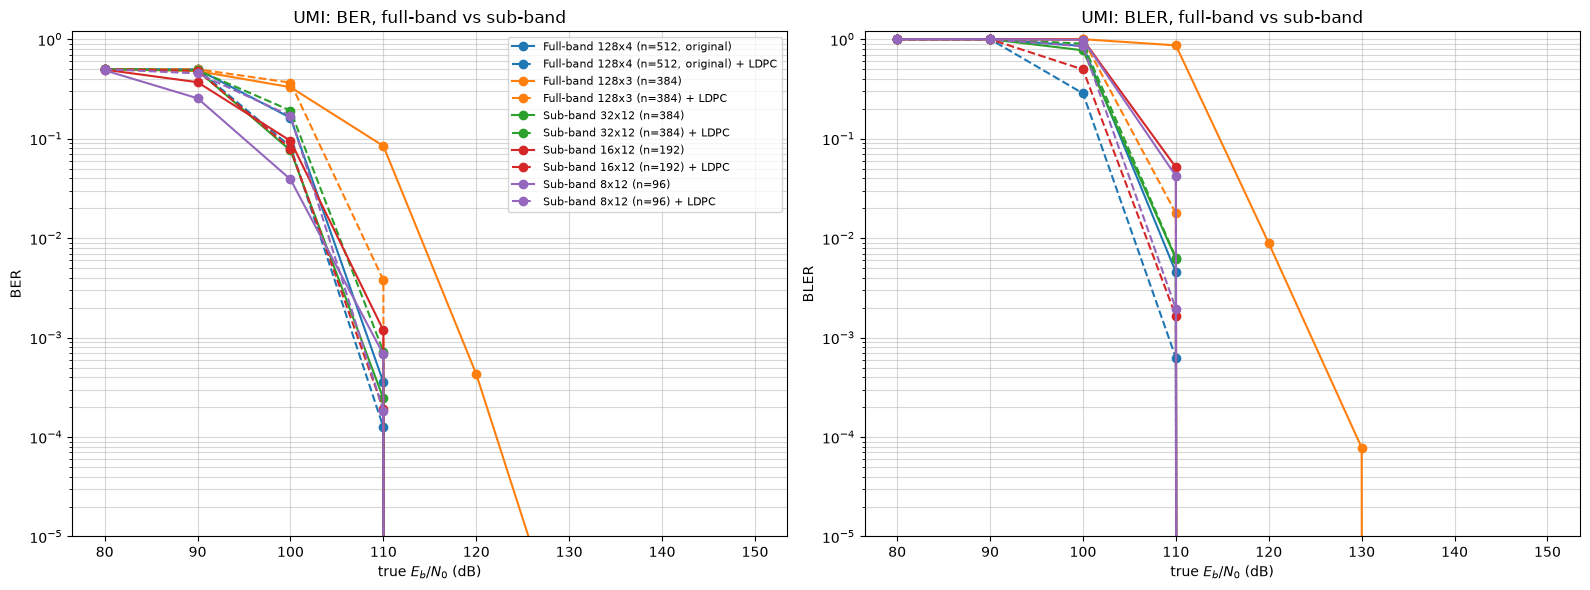

config                                         80       90      100      110      120      130      140      150
Full-band 128x4 (n=512, original)         5.0e-01  5.0e-01  1.6e-01  3.6e-04  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Full-band 128x4 (n=512, original) +LDPC   5.0e-01  5.0e-01  8.3e-02  1.3e-04  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Full-band 128x3 (n=384)                   5.0e-01  4.8e-01  3.3e-01  8.4e-02  4.3e-04  5.3e-07  0.0e+00  0.0e+00
Full-band 128x3 (n=384) +LDPC             5.0e-01  5.0e-01  3.7e-01  3.8e-03  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Sub-band 32x12 (n=384)                    5.0e-01  4.9e-01  7.6e-02  2.4e-04  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Sub-band 32x12 (n=384) +LDPC              5.0e-01  4.9e-01  1.9e-01  7.2e-04  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Sub-band 16x12 (n=192)                    4.9e-01  3.7e-01  9.5e-02  1.2e-03  0.0e+00  0.0e+00  0.0e+00  0.0e+00
Sub-band 16x12 (n=192) +LDPC              5.0e-01  4.8e-01  7.9e-02  1.9e-04  0.0e+00  0.0e+00  

In [27]:
cmap = plt.get_cmap("tab10")
for scenario in SB["scenarios"]:
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    for i, (label, *_ ) in enumerate(SB_CONFIGS):
        for use_ldpc, ls in [(False, "-"), (True, "--")]:
            ber, bler = SB["results"][(scenario, label, use_ldpc)]
            tag = f"{label}{' + LDPC' if use_ldpc else ''}"
            ax[0].semilogy(SB["ebno_db"], ber,  ls, color=cmap(i), marker="o", label=tag)
            ax[1].semilogy(SB["ebno_db"], bler, ls, color=cmap(i), marker="o", label=tag)
    for a, name in zip(ax, ["BER", "BLER"]):
        a.set_xlabel(AXIS); a.set_ylabel(name); a.grid(True, which="both", alpha=0.5)
        a.set_ylim([1e-5, 1.2]); a.set_title(f"{scenario.upper()}: {name}, full-band vs sub-band")
    ax[0].legend(fontsize=8)
    plt.tight_layout(); plt.show()

# Summary: BER at each Eb/No
print(f"{'config':40s}" + "".join(f"{e:>9.0f}" for e in SB["ebno_db"]))
for scenario in SB["scenarios"]:
    for label, *_ in SB_CONFIGS:
        for use_ldpc in [False, True]:
            ber = SB["results"][(scenario, label, use_ldpc)][0]
            print(f"{(label + (' +LDPC' if use_ldpc else ''))[:40]:40s}" + "".join(f"{v:9.1e}" for v in ber))

### Eve check: does sub-banding keep the security gap?

Eve decodes with the public basis `B`. Her BER should stay near 0.5 for every configuration.
Small tiles (n = 96, 192) are weak on their own against lattice attacks. That is why each tile has its own basis (`distinct_bases=True`). In the full design, all these bases would be generated from one ML-KEM shared secret and refreshed each session.

In [28]:
EVE_CONFIGS = [("Sub-band 32x12 (n=384)", 32, 12), ("Sub-band 8x12 (n=96)", 8, 12)]
EVE = {}
for label, w, T in EVE_CONFIGS:
    print(f"\n=== Eve | {label} ===")
    m = SubbandModel("umi", band_width=w, band_time=T, distinct_bases=True, eve=True, normalize_power=TRUE_SNR)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=SB["batch_size"], num_bs=1, num_ut=m._num_ut)
    ber, bler = sim_ber(m, SB["ebno_db"], batch_size=SB["batch_size"], max_mc_iter=5,
                        num_target_block_errors=50, compile_mode=None)
    EVE[label] = ber.cpu().numpy()
    print(label, "Eve BER:", np.round(EVE[label], 3))


=== Eve | Sub-band 32x12 (n=384) ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     80.0 | 4.9976e-01 | 1.0000e+00 |      786048 |     1572864 |          256 |         256 |         5.8 |reached target block errors
     90.0 | 4.9865e-01 | 1.0000e+00 |      784316 |     1572864 |          256 |         256 |         5.8 |reached target block errors
    100.0 | 4.9624e-01 | 1.0000e+00 |      780517 |     1572864 |          256 |         256 |         5.8 |reached target block errors
    110.0 | 4.9118e-01 | 1.0000e+00 |      772565 |     1572864 |          256 |         256 |         5.8 |reached target block errors
    120.0 | 4.7673e-01 | 1.0000e+00 |      749829 |     1572864 |          256 |         256 |         5.8 |reached target block errors
    130.0 | 4.4292e-01 | 1.

### Image transmission with sub-band encryption

Sends the same test image through each configuration and reports PSNR and SSIM, so the results can be compared with the image-encryption papers (which use an AWGN channel only).

Full-band 128x3          Eb/No=100 dB  PSNR= 11.01 dB  SSIM=0.1694
Full-band 128x3          Eb/No=110 dB  PSNR= 14.35 dB  SSIM=0.4259
Full-band 128x3          Eb/No=120 dB  PSNR=   inf dB  SSIM=1.0000
Sub-band 32x12           Eb/No=100 dB  PSNR= 12.97 dB  SSIM=0.4790
Sub-band 32x12           Eb/No=110 dB  PSNR= 29.04 dB  SSIM=0.9667
Sub-band 32x12           Eb/No=120 dB  PSNR=   inf dB  SSIM=1.0000
Sub-band 32x12 + LDPC    Eb/No=100 dB  PSNR= 11.82 dB  SSIM=0.2051
Sub-band 32x12 + LDPC    Eb/No=110 dB  PSNR= 19.03 dB  SSIM=0.7314
Sub-band 32x12 + LDPC    Eb/No=120 dB  PSNR=   inf dB  SSIM=1.0000


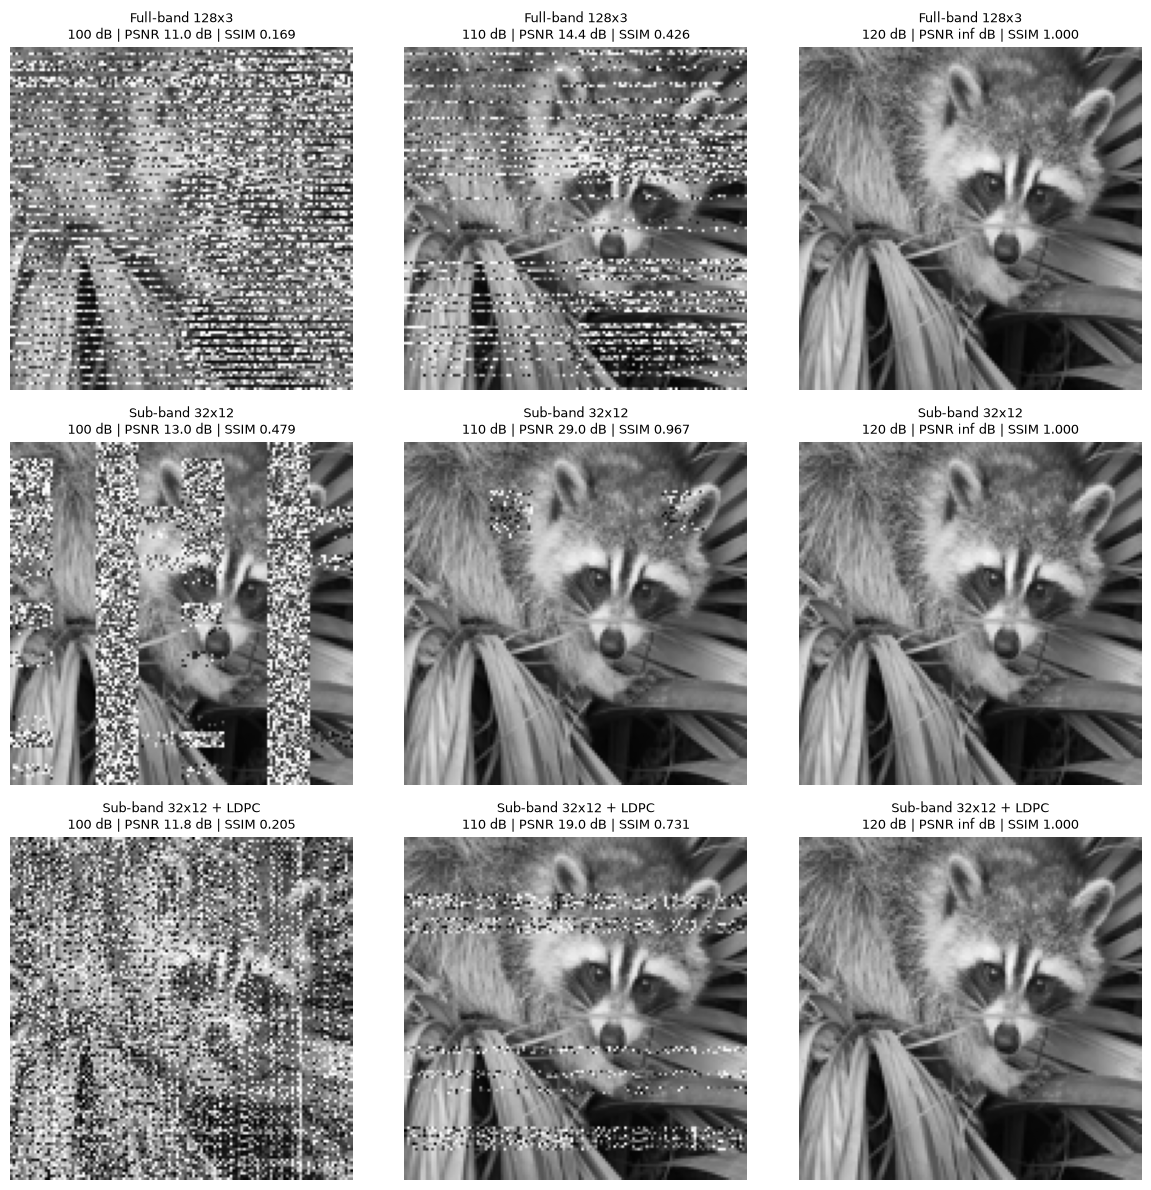

In [29]:
def send_image_bits(model, bits_np, ebno_db, batch_size=16):
    k, ntx = model._k, model._num_tx
    per_batch = batch_size * ntx * k
    pad = (-len(bits_np)) % per_batch
    b_all = np.concatenate([bits_np, np.zeros(pad)])
    out = []
    for i in range(0, len(b_all), per_batch):
        b = torch.tensor(b_all[i:i+per_batch], dtype=torch.float64).reshape(batch_size, ntx, 1, k)
        if torch.cuda.is_available(): b = b.cuda()
        _, b_hat = model.run_bits(b, torch.tensor(ebno_db, dtype=torch.float64))
        out.append(b_hat.reshape(-1).cpu().numpy())
    return np.concatenate(out)[:len(bits_np)]

def psnr(a, b):
    mse = np.mean((a.astype(float) - b.astype(float)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    ssim = None

res = 128
img = np.array(Image.open(image_path).convert("L").resize((res, res)), dtype=np.uint8)
bits = np.unpackbits(img.flatten()).astype(np.float64)

IMG_EBNO = [100, 110, 120] if TRUE_SNR else [50, 60, 70]
IMG_CONFIGS = [("Full-band 128x3", 128, 3, False), ("Sub-band 32x12", 32, 12, False),
               ("Sub-band 32x12 + LDPC", 32, 12, True)]
fig, axes = plt.subplots(len(IMG_CONFIGS), len(IMG_EBNO), figsize=(4 * len(IMG_EBNO), 4 * len(IMG_CONFIGS)))
for r, (label, w, T, ldpc) in enumerate(IMG_CONFIGS):
    m = SubbandModel("umi", band_width=w, band_time=T, distinct_bases=True, use_ldpc=ldpc, normalize_power=TRUE_SNR)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=16, num_bs=1, num_ut=m._num_ut)
    for c, e in enumerate(IMG_EBNO):
        rx = np.packbits(send_image_bits(m, bits, e).astype(np.uint8)).reshape(res, res)
        p = psnr(img, rx); s = ssim(img, rx, data_range=255) if ssim else float("nan")
        axes[r, c].imshow(rx, cmap="gray", vmin=0, vmax=255); axes[r, c].axis("off")
        axes[r, c].set_title(f"{label}\n{e} dB | PSNR {p:.1f} dB | SSIM {s:.3f}", fontsize=9)
        print(f"{label:24s} Eb/No={e} dB  PSNR={p:6.2f} dB  SSIM={s:.4f}")
plt.tight_layout(); plt.show()

## Image Encryption Analysis

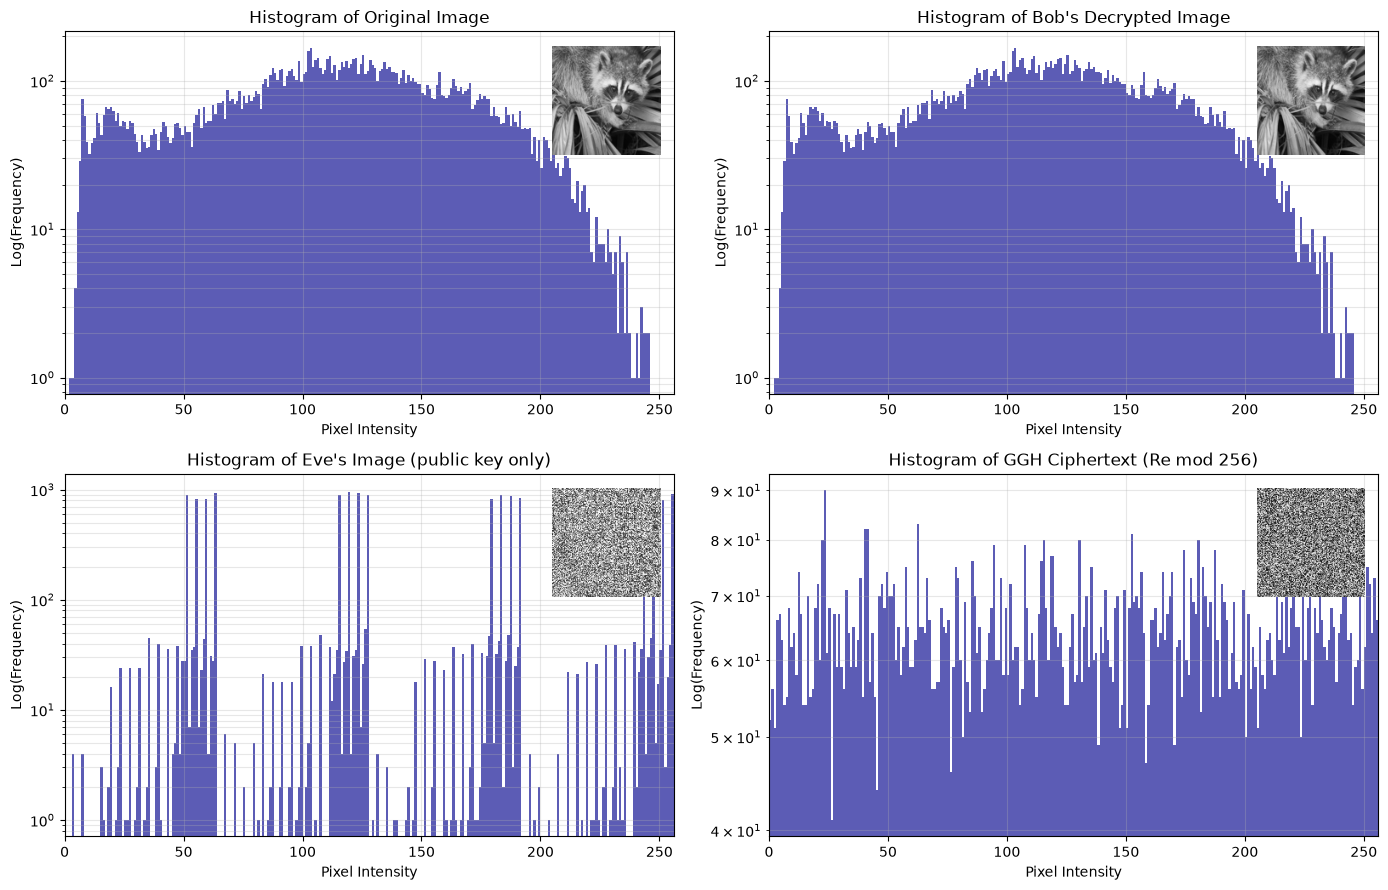

Image                                   Mean    Variance   Entropy
------------------------------------------------------------------
Original Image                        113.48      2611.1     7.635
Bob's Decrypted Image                 113.48      2611.1     7.635
Eve's Image (public key only)         151.46      5156.5     4.899
GGH Ciphertext (Re mod 256)           127.93      5449.5     7.989

Ciphertext real-part range (before mod 256): -2.788e+07 to 2.573e+07


In [30]:
# ============================================================
# Pixel histograms + stats table (Shankar & Mishra, Fig. 3-5 / Table II style)
# Run AFTER the image transmission cell.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def entropy8(a):
    """Shannon entropy of an 8-bit image (ideal = 8 bits)."""
    counts = np.bincount(np.asarray(a, dtype=np.uint8).ravel(), minlength=256)
    p = counts[counts > 0] / counts.sum()
    return float(-(p * np.log2(p)).sum())

# --- Ciphertext as a "pixel image" -------------------------------------------
# GGH ciphertext values are huge and not reduced mod q, so (like Shankar's mod-q
# encrypted image) we show Re(ciphertext) mod 256 for visualisation only.
with torch.no_grad():
    eng = bob_model._lattice_engine
    x = bob_model._mapper(b_input.to(torch.float64)).to(torch.complex128)
    x = x.reshape(-1, bob_model._lattice_n)
    eng.B = eng.B.to(device=x.device, dtype=torch.complex128)
    qs = 10 ** 0.5
    c = eng.encrypt(x * qs)                      # ciphertext in the lattice domain
c_real = c.real.flatten().cpu().numpy()
cipher_img = (np.round(c_real[:res * res]) % 256).astype(np.uint8).reshape(res, res)

# --- Histograms ----------------------------------------------------------------
panels = [
    ("Histogram of Original Image",                 img_resized),
    ("Histogram of Bob's Decrypted Image",          bob_res),
    ("Histogram of Eve's Image (public key only)",  eve_res),
    ("Histogram of GGH Ciphertext (Re mod 256)",    cipher_img),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (title, im) in zip(axes.ravel(), panels):
    ax.hist(np.asarray(im).ravel(), bins=256, range=(0, 256),
            color="#3F3FA8", alpha=0.85, edgecolor="none")
    ax.set_yscale("log")
    ax.set_xlim(0, 256)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Log(Frequency)")
    ax.grid(True, which="both", alpha=0.3)
    inset = ax.inset_axes([0.80, 0.66, 0.18, 0.30])   # thumbnail, top-right
    inset.imshow(im, cmap="gray", vmin=0, vmax=255)
    inset.axis("off")
plt.tight_layout()
plt.show()

# --- Stats table (like Shankar & Mishra Table II) -------------------------------
print(f"{'Image':34s}{'Mean':>10s}{'Variance':>12s}{'Entropy':>10s}")
print("-" * 66)
for title, im in panels:
    a = np.asarray(im, dtype=np.float64)
    name = title.replace("Histogram of ", "")
    print(f"{name:34s}{a.mean():10.2f}{a.var():12.1f}{entropy8(im):10.3f}")
print(f"\nCiphertext real-part range (before mod 256): "
      f"{c_real.min():.3e} to {c_real.max():.3e}")

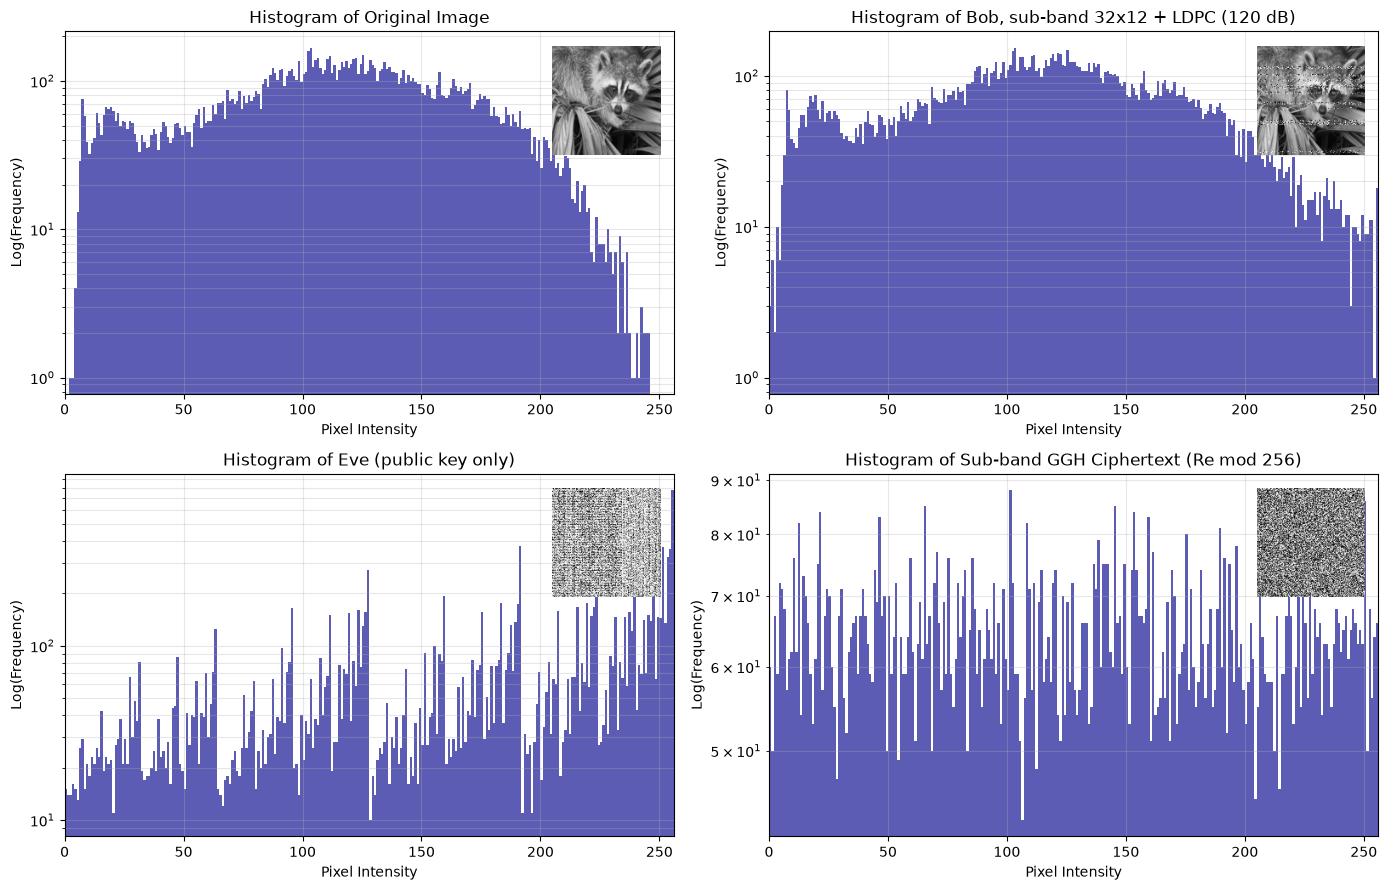

Image                                             Mean    Variance   Entropy
----------------------------------------------------------------------------
Original Image                                  113.48      2611.1     7.635
Bob, sub-band 32x12 + LDPC (120 dB)             115.67      2997.9     7.735
Eve (public key only)                           168.23      5190.9     7.353
Sub-band GGH Ciphertext (Re mod 256)            126.93      5446.6     7.987


In [31]:
# ============================================================
# Histograms for the SUB-BAND 32x12 + LDPC version
# Run AFTER the sub-band image transmission cell.
# ============================================================
EBNO_HIST = 120 if TRUE_SNR else 60

m = SubbandModel("umi", band_width=32, band_time=12, distinct_bases=True, use_ldpc=True, normalize_power=TRUE_SNR)
if torch.cuda.is_available(): m.cuda()
m._channel_model.allocate_topology_tensors(batch_size=16, num_bs=1, num_ut=m._num_ut)

# --- Bob and Eve use the SAME keys (same model, only the decoding basis changes) ---
bob_sb = np.packbits(send_image_bits(m, bits, EBNO_HIST).astype(np.uint8)).reshape(res, res)
m._eve = True
eve_sb = np.packbits(send_image_bits(m, bits, EBNO_HIST).astype(np.uint8)).reshape(res, res)
m._eve = False

# --- Ciphertext: LDPC encode -> interleave -> QAM -> tiles -> encrypt each tile ---
with torch.no_grad():
    k, ntx = m._k, m._num_tx
    n_batch = 3                                   # 3 x 4 users x 1536 symbols > 128*128 values
    need = n_batch * ntx * k
    b_np = np.resize(bits, need)                  # repeat image bits to fill the frames
    b = torch.tensor(b_np, dtype=torch.float64).reshape(n_batch, ntx, 1, k)
    if torch.cuda.is_available(): b = b.cuda()
    c_bits = m._encoder(b)[..., m._ilv.to(b.device)]
    xt = m._to_tiles(m._mapper(c_bits).to(torch.complex128))
    cts = []
    for g in range(m._num_tiles):
        eng = m._engine(g)
        eng.B = eng.B.to(device=xt.device, dtype=torch.complex128)
        cts.append(eng.encrypt(xt[..., g, :].reshape(-1, m._n_sub) * 10**0.5))
    c_real = torch.cat(cts).real.flatten().cpu().numpy()
cipher_sb = (np.round(c_real[:res * res]) % 256).astype(np.uint8).reshape(res, res)

# --- Plot + stats (reuses entropy8 from the previous histogram cell) ---
panels = [
    ("Original Image",                           img),
    (f"Bob, sub-band 32x12 + LDPC ({EBNO_HIST} dB)", bob_sb),
    ("Eve (public key only)",                    eve_sb),
    ("Sub-band GGH Ciphertext (Re mod 256)",     cipher_sb),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (title, im) in zip(axes.ravel(), panels):
    ax.hist(np.asarray(im).ravel(), bins=256, range=(0, 256), color="#3F3FA8", alpha=0.85)
    ax.set_yscale("log"); ax.set_xlim(0, 256)
    ax.set_title("Histogram of " + title, fontsize=12)
    ax.set_xlabel("Pixel Intensity"); ax.set_ylabel("Log(Frequency)")
    ax.grid(True, which="both", alpha=0.3)
    inset = ax.inset_axes([0.80, 0.66, 0.18, 0.30])
    inset.imshow(im, cmap="gray", vmin=0, vmax=255); inset.axis("off")
plt.tight_layout(); plt.show()

print(f"{'Image':44s}{'Mean':>10s}{'Variance':>12s}{'Entropy':>10s}")
print("-" * 76)
for title, im in panels:
    a = np.asarray(im, dtype=np.float64)
    print(f"{title:44s}{a.mean():10.2f}{a.var():12.1f}{entropy8(im):10.3f}")

## Security vs. SNR trade-off for GGH (Shankar Fig. 6 analogue)

A "bad" public basis B is what protects GGH against Eve. We get it by mixing the private basis with a random unimodular matrix: more mixing `rounds` and larger `max_coeff` give a smaller Hadamard ratio HR(B), which is more secure. But the ciphertext C = S·Bᵀ + E is built from the long vectors of B, so it also gets **larger**. After power normalisation, a larger ciphertext means more SNR is needed.

This test uses AWGN only (no MIMO) with n = 192, the size of a 16×12 tile. For each key it reports HR(B) (secure if ≤ 10⁻³), the ciphertext power, and the smallest true Es/N0 at which every block decrypts correctly.

rounds=1 coeff=1  HR(B)=5.2e-01  ciphertext power=  35.9 dB  required true Es/N0=  35.0 dB  NOT secure
rounds=1 coeff=2  HR(B)=3.1e-01  ciphertext power=  49.1 dB  required true Es/N0=  47.5 dB  NOT secure
rounds=1 coeff=3  HR(B)=2.2e-01  ciphertext power=  56.3 dB  required true Es/N0=  55.0 dB  NOT secure
rounds=2 coeff=1  HR(B)=3.2e-01  ciphertext power=  40.2 dB  required true Es/N0=  40.0 dB  NOT secure
rounds=2 coeff=2  HR(B)=1.2e-01  ciphertext power=  55.8 dB  required true Es/N0=  55.0 dB  NOT secure
rounds=2 coeff=3  HR(B)=5.2e-02  ciphertext power=  73.4 dB  required true Es/N0=  75.0 dB  NOT secure
rounds=3 coeff=1  HR(B)=1.9e-01  ciphertext power=  44.7 dB  required true Es/N0=  45.0 dB  NOT secure
rounds=3 coeff=2  HR(B)=3.9e-02  ciphertext power=  65.4 dB  required true Es/N0=  65.0 dB  NOT secure
rounds=3 coeff=3  HR(B)=9.8e-03  ciphertext power=  97.8 dB  required true Es/N0=  97.5 dB  NOT secure
rounds=4 coeff=1  HR(B)=1.2e-01  ciphertext power=  49.2 dB  required tru

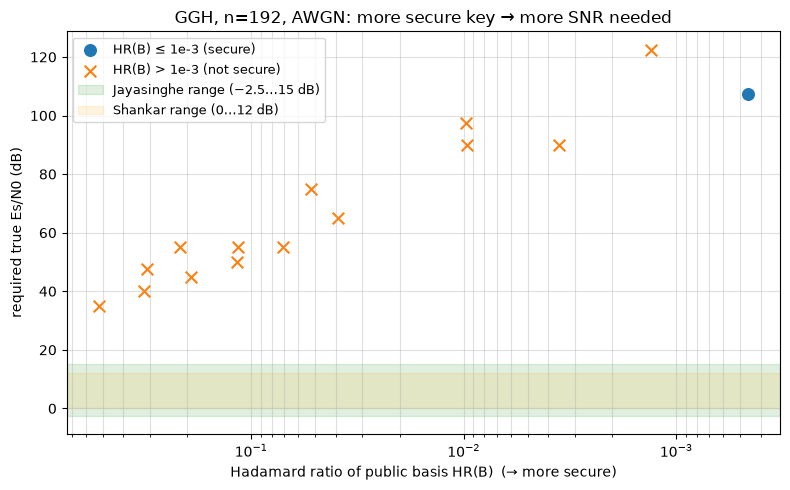

In [32]:
def ggh_required_snr(eng, n, snr_grid, num_blocks=64):
    """Smallest true Es/N0 (dB) on snr_grid at which all num_blocks blocks decrypt without error."""
    lv = torch.tensor([-3., -1., 1., 3.], dtype=torch.float64)
    S = (lv[torch.randint(0, 4, (num_blocks, n))] + 1j * lv[torch.randint(0, 4, (num_blocks, n))]).to(torch.complex128)
    C = eng.encrypt(S)                                     # lattice domain (integer QAM levels)
    P = (C.abs() ** 2).mean().item()                       # transmit C/sqrt(P) -> unit power
    R = eng.R.to(torch.complex128); R_inv = torch.linalg.pinv(R); B_inv = eng.B_inv
    for snr in snr_grid:
        no = 10 ** (-snr / 10)
        N = np.sqrt(no * P / 2) * (torch.randn(C.shape, dtype=torch.float64) + 1j * torch.randn(C.shape, dtype=torch.float64))
        Y = (C + N) @ R_inv.T
        S_hat = ((torch.round(Y.real) + 1j * torch.round(Y.imag)) @ R.T) @ B_inv.T
        if bool(((S_hat - S).abs() < 0.5).all()):
            return snr, P
    return float("nan"), P

SEC = []
snr_grid = np.arange(0, 200.1, 2.5)
n_sec = 192
for rounds in [1, 2, 3, 4, 5]:
    for max_coeff in [1, 2, 3]:
        eng = LatticeBasedEncryptor(n=n_sec, rounds=rounds, max_coeff=max_coeff, verbose=False)
        snr_req, P = ggh_required_snr(eng, n_sec, snr_grid)
        SEC.append(dict(rounds=rounds, max_coeff=max_coeff, hr_B=eng.info["hr_B"], P_db=10 * np.log10(P / 10),
                        snr_req=snr_req, secure=eng.info["hr_B"] <= 1e-3))
        print(f"rounds={rounds} coeff={max_coeff}  HR(B)={eng.info['hr_B']:.1e}  "
              f"ciphertext power={10*np.log10(P/10):6.1f} dB  required true Es/N0={snr_req:6.1f} dB  "
              f"{'secure' if eng.info['hr_B'] <= 1e-3 else 'NOT secure'}")

fig, ax = plt.subplots(figsize=(8, 5))
for sec_flag, mk, lab in [(True, "o", "HR(B) ≤ 1e-3 (secure)"), (False, "x", "HR(B) > 1e-3 (not secure)")]:
    pts = [r for r in SEC if r["secure"] == sec_flag]
    ax.scatter([r["hr_B"] for r in pts], [r["snr_req"] for r in pts], marker=mk, s=70, label=lab)
ax.set_xscale("log"); ax.invert_xaxis()
ax.axhspan(-2.5, 15, color="green", alpha=0.12, label="Jayasinghe range (−2.5…15 dB)")
ax.axhspan(0, 12, color="orange", alpha=0.12, label="Shankar range (0…12 dB)")
ax.set_xlabel("Hadamard ratio of public basis HR(B)  (→ more secure)")
ax.set_ylabel("required true Es/N0 (dB)")
ax.set_title(f"GGH, n={n_sec}, AWGN: more secure key → more SNR needed")
ax.grid(True, which="both", alpha=0.4); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Replacing GGH with standardised LWE (ML-KEM / FrodoKEM)

**Why GGH is not a good baseline for the MIMO uplink**
- **Outdated and broken.** GGH was broken in practice by Nguyen (1999) and by Nguyen–Regev (2006, "learning a parallelepiped"). No standards body recommends it.
- **No modulus, so the power is unbounded.** The ciphertext C = S·Bᵀ + E is built from the long vectors of the bad public basis B. The more secure the key, the larger the ciphertext: about 10¹¹–10¹² times the power of a 16-QAM symbol with our keys. After fair power normalisation, Bob needs **~110–120 dB true Eb/N0** (see the true-SNR sweeps and the security-vs-SNR sweep above).

**Standardised LWE alternatives.** All work modulo q, so every ciphertext value lies in [−q/2, q/2). The transmit power is fixed whatever the security level, and channel noise simply adds to the LWE noise.

| Standard | Problem | Parameters (n, q) | Message bits / coefficient | Status |
|---|---|---|---|---|
| **ML-KEM-512 / 768 / 1024** (NIST FIPS 203, 2024) | Module-LWE (Kyber) | 256·k, 3329 (k = 2, 3, 4) | 1 | NIST standard; being adopted in TLS, 3GPP and IETF |
| **FrodoKEM-640 / 976 / 1344** (ISO/IEC 18033-2 Amd 2, 2026) | plain LWE | 640 / 976 / 1344, 2¹⁵ / 2¹⁶ / 2¹⁶ | 2 / 3 / 4 | ISO standard; recommended by BSI and ANSSI as the conservative option |
| (Lindner–Peikert 2011, used in our first prototype) | plain LWE | 192, 4093 | 1 | academic only; noticeable decryption-noise floor |

**How we use them at the physical layer (per sub-band tile)**
1. The BS publishes its ML-KEM / FrodoKEM public key. Each UE runs **ML-KEM.Encaps** once per session over the control channel, giving a 32-byte shared secret K. (Simulated here with `os.urandom`.)
2. For every tile, UE and BS derive the encryption randomness (r, e1, e2) from K with SHAKE-256 (FIPS 202).
3. The UE sends only `v = tᵀr + e2 + Encode(m)` (mod q) on the I and Q parts of the tile's REs, scaled to unit power. `u = Aᵀr + e1` depends only on r, e1, so the BS rebuilds it from K and **it is not sent**.
4. The BS decrypts `v − sᵀu`, which is the standard K-PKE / FrodoPKE decryption (`secret_key` mode). Alternatively it subtracts the whole mask rebuilt from K (`keystream` mode).

FIPS 203 says K-PKE "shall not be used as a stand-alone scheme". Here the **key exchange is the standard ML-KEM (with its FO transform)**, and K-PKE-style masking is used only as a lattice-structured, bounded-power cipher inside the session. As with GGH, this gives confidentiality only; integrity would need a MAC or ML-DSA (future work).

**Tile size.** ML-KEM encrypts one 256-coefficient polynomial per encryption, which is 128 REs (I + Q). A **32 subcarrier × 4 symbol tile carries exactly one ML-KEM ciphertext**. FrodoKEM works in rows of 8 coefficients, so any tile fits.

In [33]:
import os, hashlib
from statistics import NormalDist

# Parameter sets. q, noise and bits per coefficient follow the standards.
PQC_PARAMS = {
    # NIST FIPS 203 (ML-KEM): Module-LWE over Z_q[X]/(X^256+1), centred-binomial noise
    "ML-KEM-512":    dict(kind="mlwe", k=2, q=3329, eta1=3, eta2=2, bits=1),
    "ML-KEM-768":    dict(kind="mlwe", k=3, q=3329, eta1=2, eta2=2, bits=1),
    "ML-KEM-1024":   dict(kind="mlwe", k=4, q=3329, eta1=2, eta2=2, bits=1),
    # ISO/IEC 18033-2 Amd 2 (FrodoKEM): plain LWE, rounded-Gaussian noise, B bits per coefficient
    "FrodoKEM-640":  dict(kind="lwe", n=640,  q=2**15, sigma=2.8, bits=2),
    "FrodoKEM-976":  dict(kind="lwe", n=976,  q=2**16, sigma=2.3, bits=3),
    "FrodoKEM-1344": dict(kind="lwe", n=1344, q=2**16, sigma=1.4, bits=4),
}

def pqc_noise_var(p):
    """Variance of Bob's decryption noise e^T r + e2 - s^T e1 (per coefficient)."""
    if p["kind"] == "mlwe":
        kn, v1, v2 = p["k"] * 256, p["eta1"] / 2, p["eta2"] / 2      # CBD_eta has variance eta/2
        return kn * v1 * v1 + kn * v1 * v2 + v2
    s2 = p["sigma"] ** 2
    return 2 * p["n"] * s2 * s2 + s2

def negacyclic(a):
    """Matrix M with M @ b = a*b in Z[X]/(X^n + 1)."""
    n = a.shape[-1]
    d = torch.arange(n).unsqueeze(1) - torch.arange(n).unsqueeze(0)
    return torch.where(d >= 0, a[d % n], -a[d % n])

def _gen(seed_bytes, label):
    """torch.Generator seeded from SHAKE-256(seed || label) (stand-in for the standards' XOF/PRF)."""
    h = hashlib.shake_256(seed_bytes + label).digest(8)
    return torch.Generator().manual_seed(int.from_bytes(h, "little") >> 1)

class PQCTileCipher:
    """Bounded-power LWE cipher for one sub-band tile, with ML-KEM or FrodoKEM parameters.

    Row convention (one row = one encryption):
        u    = r U + e1           (not transmitted; rebuilt by the BS from the session key)
        mask = r V + e2
        v    = mask + Encode(m)   (mod q)  -> sent over the air
        Bob: v - u D = Encode(m) + noise   ('secret_key')   or   v - mask   ('keystream')
    ML-KEM: U, V, D are the negacyclic (ring) expansions of A^T, t, s; one row = 256 coefficients.
    FrodoKEM: U = A, V = B = A S + E, D = S; one row = n_bar = 8 coefficients.
    """
    def __init__(self, scheme="ML-KEM-768", bits=None, keygen_seed=None):
        p = PQC_PARAMS[scheme]
        self.scheme, self.p, self.q = scheme, p, p["q"]
        self.bits = p["bits"] if bits is None else bits            # bits != standard -> non-standard encoding
        d = os.urandom(32) if keygen_seed is None else hashlib.sha3_256(str(keygen_seed).encode()).digest()
        rho, sigma = hashlib.sha3_512(d).digest()[:32], hashlib.sha3_512(d).digest()[32:]   # public / secret seeds
        gA, gs = _gen(rho, b"A"), _gen(sigma, b"s")
        q = self.q
        if p["kind"] == "mlwe":
            k, n = p["k"], 256
            A = torch.randint(0, q, (k, k, n), generator=gA).to(torch.float64)
            s, e = self._noise((k, n), gs, p["eta1"]), self._noise((k, n), gs, p["eta1"])
            A_big = torch.cat([torch.cat([negacyclic(A[i, j]) for j in range(k)], 1) for i in range(k)], 0)
            AT_big = torch.cat([torch.cat([negacyclic(A[j, i]) for j in range(k)], 1) for i in range(k)], 0)
            t = torch.remainder(A_big @ s.reshape(-1) + e.reshape(-1), q).reshape(k, n)
            self.U = AT_big.T.contiguous()                                                 # kn x kn
            self.V = torch.cat([negacyclic(t[i]) for i in range(k)], 1).T.contiguous()    # kn x 256
            self.D = torch.cat([negacyclic(s[i]) for i in range(k)], 1).T.contiguous()    # kn x 256
            self.dim, self.Lb = k * n, n
        else:
            n, nbar = p["n"], 8
            A = torch.randint(0, q, (n, n), generator=gA).to(torch.float64)
            S, E = self._noise((n, nbar), gs, None), self._noise((n, nbar), gs, None)
            self.U, self.D = A, S
            self.V = torch.remainder(A @ S + E, q)
            self.dim, self.Lb = n, nbar
        self.UD = torch.remainder(self.U @ self.D, q)       # u D = r (U D) + e1 D: no need to form u
        self.noise_var = pqc_noise_var(p)
        self.coeff_std = q / np.sqrt(12.0)                   # std of a uniform mod-q value
        self.new_session()

    def new_session(self):
        """Shared session key K (stand-in for the output of ML-KEM.Encaps / Decaps)."""
        self.K = os.urandom(32)
        self.gen = _gen(self.K, b"tile-randomness")

    def _noise(self, shape, g, eta):
        if self.p["kind"] == "mlwe":                          # centred binomial CBD_eta
            b = torch.randint(0, 2, (*shape, 2 * eta), generator=g).to(torch.float64)
            return b[..., :eta].sum(-1) - b[..., eta:].sum(-1)
        return torch.round(torch.randn(shape, generator=g, dtype=torch.float64) * self.p["sigma"])

    def centre(self, x):
        return torch.remainder(x + self.q / 2, self.q) - self.q / 2

    def encrypt(self, m):
        """m: [N, L] integers in 0..2^bits-1, L a multiple of Lb. Returns (v, uD, mask), each [N, L]."""
        N, L = m.shape
        rows = N * L // self.Lb
        dev = m.device
        eta1, eta2 = self.p.get("eta1"), self.p.get("eta2")
        r = self._noise((rows, self.dim), self.gen, eta1).to(dev)
        e1 = self._noise((rows, self.dim), self.gen, eta2).to(dev)
        e2 = self._noise((rows, self.Lb), self.gen, eta2).to(dev)
        V, UD, D = self.V.to(dev), self.UD.to(dev), self.D.to(dev)
        mask = torch.remainder(r @ V + e2, self.q)
        uD = torch.remainder(r @ UD + e1 @ D, self.q)
        enc = torch.round(m.reshape(rows, self.Lb).to(torch.float64) * self.q / 2 ** self.bits)
        v = torch.remainder(mask + enc, self.q)
        return v.reshape(N, L), uD.reshape(N, L), mask.reshape(N, L)

    def unmask(self, v_rx, uD, mask, mode):
        if mode == "secret_key":
            v = v_rx - uD
        elif mode == "keystream":
            v = v_rx - mask
        elif mode == "eve":                                   # no K, no s: nothing to subtract
            v = v_rx
        else:
            raise ValueError(mode)
        return torch.remainder(v, self.q)

    def llr(self, v, noise_var):
        """Max-log LLRs, log p(b=1)/p(b=0), Gray-labelled points j*q/2^bits on the mod-q circle."""
        M = 2 ** self.bits
        pts = torch.round(torch.arange(M, dtype=torch.float64, device=v.device) * self.q / M)
        d = self.centre(v.unsqueeze(-1) - pts)
        metric = -(d ** 2) / (2 * noise_var.unsqueeze(-1))
        labels = gray_labels(self.bits).to(v.device).bool()
        out = [metric.masked_fill(~labels[:, b], -float("inf")).amax(-1)
               - metric.masked_fill(labels[:, b], -float("inf")).amax(-1) for b in range(self.bits)]
        return torch.stack(out, -1).reshape(*v.shape[:-1], -1)

def gray_labels(bits):
    g = [j ^ (j >> 1) for j in range(2 ** bits)]
    return torch.tensor([[(x >> (bits - 1 - b)) & 1 for b in range(bits)] for x in g])

def bits_to_symbols(b, bits):
    """[..., L*bits] 0/1 -> [..., L] integers (inverse of the Gray labelling above)."""
    b = b.reshape(*b.shape[:-1], -1, bits).to(torch.int64)
    val = torch.zeros(b.shape[:-1], dtype=torch.int64, device=b.device)
    for i in range(bits):
        val = val * 2 + b[..., i]
    idx, shift = val.clone(), val >> 1
    while bool(shift.any()):
        idx ^= shift
        shift >>= 1
    return idx

### Noise budget: why standard LWE works at realistic SNR (AWGN, analytic)

Bob decides each coefficient correctly if |LWE noise + channel noise| < margin = q / 2^(bits+1). With unit transmit power, the channel noise on one coefficient has variance (q²/12)·N0. The table gives the LWE noise, the margin, and the **true** Es/N0 and Eb/N0 needed for a per-coefficient error rate of 10⁻⁵ without coding (Gaussian approximation).

In [38]:
from statistics import NormalDist

def lwe_budget(q, bits, noise_var, p_target=1e-5):
    margin = q / 2 ** (bits + 1)
    gamma = NormalDist().inv_cdf(1 - p_target / 2)                 # two-sided
    fail_no_channel = 2 * (1 - NormalDist().cdf(margin / np.sqrt(noise_var))) if noise_var > 0 else 0.0
    no = (margin ** 2 / gamma ** 2 - noise_var) / (q ** 2 / 12)    # allowed channel noise (unit power)
    esno = -10 * np.log10(no) if no > 0 else float("inf")
    return margin, np.sqrt(noise_var), fail_no_channel, esno, esno - 10 * np.log10(2 * bits)

rows = []
for name, p in PQC_PARAMS.items():
    rows.append((name, p["q"], p["bits"], pqc_noise_var(p)))
rows.append(("Lindner-Peikert n=192 (old)", 4093, 1, 2 * 192 * (8.87 / np.sqrt(2 * np.pi)) ** 4 + (8.87 / np.sqrt(2 * np.pi)) ** 2))
rows.append(("no LWE noise (keystream mode), 1 bit", 3329, 1, 0.0))
rows.append(("no LWE noise (keystream mode), 2 bits", 3329, 2, 0.0))

print(f"{'scheme':38s}{'bits/RE':>8s}{'LWE std':>9s}{'margin':>8s}{'margin/std':>11s}"
      f"{'P_fail(no ch.)':>15s}{'Es/N0 req':>10s}{'Eb/N0 req':>10s}")
for name, q_, nbits, var in rows:      # not 'bits': that name holds the image bits
    margin, std, pf, esno, ebno = lwe_budget(q_, nbits, var)
    ratio = margin / std if std > 0 else float("inf")
    print(f"{name:38s}{2*nbits:8d}{std:9.1f}{margin:8.0f}{ratio:11.1f}{pf:15.1e}{esno:9.1f} {ebno:9.1f}")
print("\nFor comparison, uncoded 16-QAM (4 bits/RE) needs about Eb/N0 = 13.4 dB for BER 1e-5 on AWGN.")
print("GGH with secure keys (this notebook): about 110-120 dB true Eb/N0.")

scheme                                 bits/RE  LWE std  margin margin/std P_fail(no ch.) Es/N0 req Eb/N0 req
ML-KEM-512                                   2     43.8     832       19.0        0.0e+00     14.4      11.4
ML-KEM-768                                   2     39.2     832       21.2        0.0e+00     14.3      11.3
ML-KEM-1024                                  2     45.3     832       18.4        0.0e+00     14.4      11.4
FrodoKEM-640                                 4    280.5    4096       14.6        0.0e+00     20.6      14.6
FrodoKEM-976                                 6    233.7    4096       17.5        0.0e+00     26.5      18.7
FrodoKEM-1344                                8    101.6    2048       20.2        0.0e+00     32.4      23.4
Lindner-Peikert n=192 (old)                  2    245.4    1023        4.2        3.1e-05      inf       inf
no LWE noise (keystream mode), 1 bit         2      0.0     832        inf        0.0e+00     14.2      11.1
no LWE noise (keys

In [39]:
class PQCSubbandModel(Model):
    """Sub-band LWE encryption (ML-KEM or FrodoKEM parameters) over the same MU-MIMO uplink.

    scheme              : key of PQC_PARAMS, e.g. "ML-KEM-768", "FrodoKEM-640"
    band_width/time     : tile size; 2 * w * T must be a multiple of 256 for ML-KEM (e.g. 32x4, 32x12)
    bits                : message bits per coefficient (None = the standard's value)
    mode                : "secret_key" (standard decryption with s) or "keystream" (mask rebuilt from K)
    eve                 : receiver without K and without s
    use_ldpc, coderate  : outer 5G LDPC code with soft LLRs and a random interleaver
    The transmit power is 1, so the Eb/N0 axis is the true Eb/N0.
    """
    def __init__(self, scenario, scheme="ML-KEM-768", band_width=32, band_time=4, bits=None,
                 mode="secret_key", eve=False, use_ldpc=False, coderate=0.5, perfect_csi=True, seed=0):
        super().__init__(scenario, perfect_csi=perfect_csi)
        self._perm, self._inv_perm, self._n_sub, self._num_tiles = \
            build_tile_perm(self._rg, band_width, band_time)
        self._perm_t, self._inv_perm_t = torch.tensor(self._perm), torch.tensor(self._inv_perm)
        self._pqc = PQCTileCipher(scheme, bits=bits, keygen_seed=seed)
        assert (2 * self._n_sub) % self._pqc.Lb == 0, \
            f"{scheme}: a tile must carry a multiple of {self._pqc.Lb} coefficients (2 per RE)"
        self._bits = self._pqc.bits
        self._mode = "eve" if eve else mode
        self._num_bits_per_symbol = 2 * self._bits           # message bits per RE (for ebnodb2no)
        self._amp = self._pqc.coeff_std * np.sqrt(2.0)       # coefficient units per unit-power RE

        self._use_ldpc = use_ldpc
        self._n_coded = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        if use_ldpc:
            self._coderate = coderate
            self._k = int(self._n_coded * coderate)
            self._encoder = LDPC5GEncoder(self._k, self._n_coded)
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)
            g = torch.Generator().manual_seed(seed)
            self._ilv = torch.randperm(self._n_coded, generator=g)
            self._ilv_inv = torch.argsort(self._ilv)
        else:
            self._coderate = 1.0
            self._k = self._n_coded

    def _to_blocks(self, z):                 # [..., num_data, d] -> [num_blocks, n_sub * d] (one row per tile)
        z = z[..., self._perm_t.to(z.device), :]
        return z.reshape(-1, self._n_sub * z.shape[-1])

    def _from_blocks(self, z, lead, d):      # inverse of _to_blocks
        z = z.reshape(*lead, self._num_tiles * self._n_sub, d)
        return z[..., self._inv_perm_t.to(z.device), :]

    def encrypt_bits(self, c_bits):
        """Coded bits [..., n_coded] -> (unit-power REs [..., num_data], uD, mask) (used for plots too)."""
        lead, nd = c_bits.shape[:-1], self._rg.num_data_symbols
        m = bits_to_symbols(c_bits, self._bits).reshape(*lead, nd, 2)     # (I, Q) coefficients per RE
        v, uD, mask = self._pqc.encrypt(self._to_blocks(m))
        vc = self._from_blocks(self._pqc.centre(v), lead, 2)
        return torch.complex(vc[..., 0], vc[..., 1]) / self._amp, uD, mask, v

    def run_bits(self, b, ebno_db, new_channel=True):
        if new_channel:
            self.new_topology(b.shape[0])
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)
        lead, nd = b.shape[:-1], self._rg.num_data_symbols

        # --- UE: LDPC -> interleave -> LWE per tile -> unit-power REs ---
        c_bits = self._encoder(b)[..., self._ilv.to(b.device)] if self._use_ldpc else b
        x, uD, mask, _ = self.encrypt_bits(c_bits)

        # --- channel + ZF ---
        y, h = self._ofdm_channel(self._rg_mapper(x), no)
        if self._perfect_csi:
            h_hat = self._remove_nulled_subcarriers(h)
            err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        else:
            h_hat, err_var = self._ls_est(y, no)
        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        # --- BS: back to mod-q coefficients, decrypt, soft demap ---
        v_rx = torch.stack([x_hat.real, x_hat.imag], -1) * self._amp
        nv = (no_eff.to(torch.float64) * self._pqc.coeff_std ** 2).unsqueeze(-1).expand(*lead, nd, 2)
        v_rx, nv = self._to_blocks(v_rx), self._to_blocks(nv.contiguous())
        if self._mode == "secret_key":
            nv = nv + self._pqc.noise_var
        llr = self._pqc.llr(self._pqc.unmask(v_rx, uD, mask, self._mode), nv).clamp(-50, 50)
        llr = self._from_blocks(llr, lead, 2 * self._bits).reshape(*lead, self._n_coded)
        if not self._use_ldpc:
            return b, (llr > 0).to(torch.float64)
        return b, self._decoder(llr[..., self._ilv_inv.to(llr.device)])

    def call(self, batch_size, ebno_db):
        b = self._binary_source([batch_size, self._num_tx, self._num_streams_per_tx, self._k])
        return self.run_bits(b, ebno_db)

### ML-KEM / FrodoKEM sub-band sweep on the true-SNR axis (UMi)

- Tile 32 × 4 (one ML-KEM ciphertext per tile), ZF, perfect CSI.
- ML-KEM carries 1 bit per coefficient (2 bits/RE, QPSK rate). FrodoKEM-640 carries 2 bits per coefficient (4 bits/RE, 16-QAM rate, like the GGH setup).
- A noiseless check runs first. Bob's BER must be 0 for every configuration; Eve's should be about 0.5.
- The shaded bands are the SNR ranges of Shankar & Mishra (0–12 dB) and Jayasinghe (−2.5–15 dB). GGH with secure keys needs about 110–120 dB, far off this chart.

noiseless | ML-KEM-768, uncoded                BER = 0.00e+00
noiseless | ML-KEM-768 + LDPC 1/2              BER = 0.00e+00
noiseless | ML-KEM-768, keystream, uncoded     BER = 0.00e+00
noiseless | FrodoKEM-640, uncoded              BER = 0.00e+00
noiseless | FrodoKEM-640 + LDPC 1/2            BER = 0.00e+00
noiseless | Eve (no K, no s), ML-KEM-768       BER = 5.02e-01

=== UMI | ML-KEM-768, uncoded | tile 32x4 ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -5.0 | 2.2565e-01 | 1.0000e+00 |       88729 |      393216 |          128 |         128 |         0.3 |reached target block errors
     -2.5 | 1.2639e-01 | 1.0000e+00 |       49700 |      393216 |          128 |         128 |         0.3 |reached target block errors
      0.0 | 4.6341e-02 | 1.0000e+00 |       18222 |   

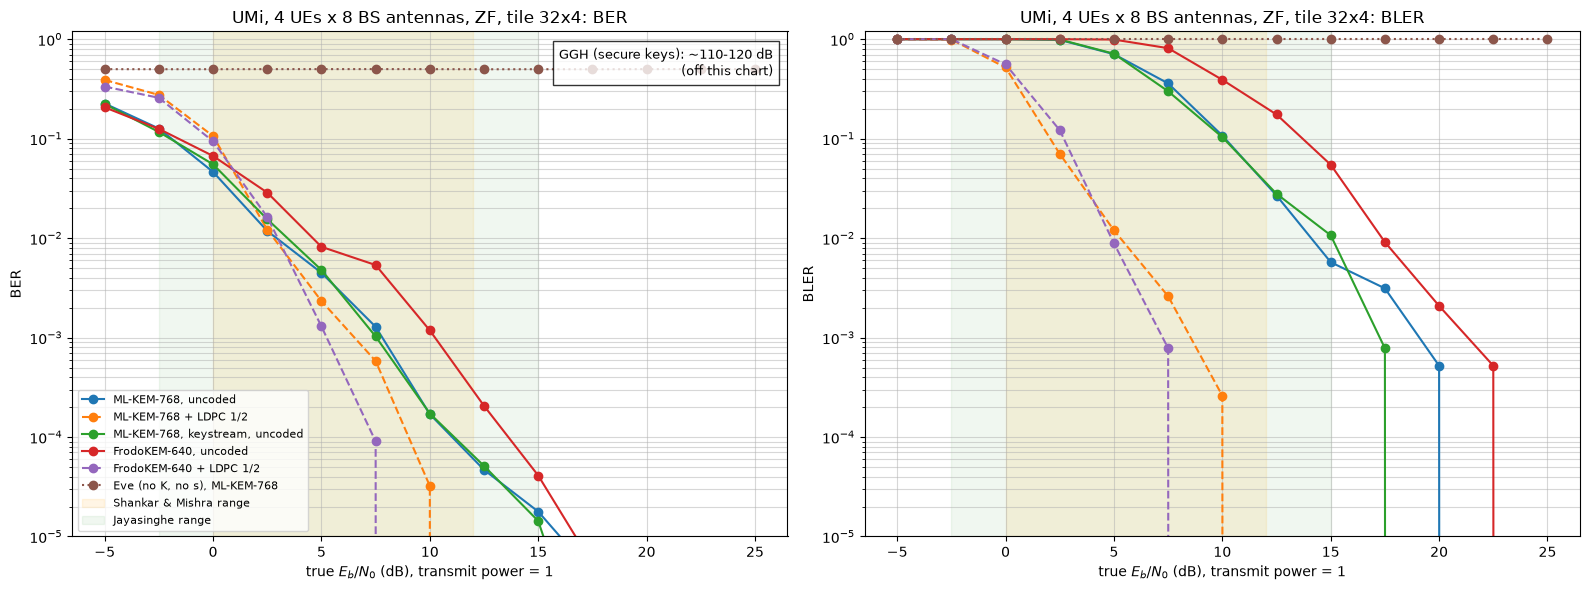

config                                  -5.0    -2.5     0.0     2.5     5.0     7.5    10.0    12.5    15.0    17.5    20.0    22.5    25.0
ML-KEM-768, uncoded                  2.3e-01 1.3e-01 4.6e-02 1.2e-02 4.5e-03 1.3e-03 1.7e-04 4.7e-05 1.8e-05 4.2e-06 5.1e-07 0.0e+00 0.0e+00
ML-KEM-768 + LDPC 1/2                3.9e-01 2.8e-01 1.1e-01 1.2e-02 2.3e-03 5.8e-04 3.2e-05 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
ML-KEM-768, keystream, uncoded       2.2e-01 1.2e-01 5.5e-02 1.5e-02 4.8e-03 1.0e-03 1.7e-04 5.1e-05 1.4e-05 3.4e-07 0.0e+00 0.0e+00 0.0e+00
FrodoKEM-640, uncoded                2.1e-01 1.3e-01 6.7e-02 2.9e-02 8.2e-03 5.4e-03 1.2e-03 2.1e-04 4.1e-05 5.3e-06 5.1e-07 1.3e-07 0.0e+00
FrodoKEM-640 + LDPC 1/2              3.3e-01 2.6e-01 9.4e-02 1.6e-02 1.3e-03 9.0e-05 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
Eve (no K, no s), ML-KEM-768         5.0e-01 5.0e-01 5.0e-01 5.0e-01 5.0e-01 5.0e-01 5.0e-01 5.0e-01 5.0e-01 5.0e-01 5.0e-01 5.0e-01 5.0e-01


In [40]:
PQC_CONFIGS = [  # (label, scheme, mode, use_ldpc, eve)
    ("ML-KEM-768, uncoded",               "ML-KEM-768",   "secret_key", False, False),
    ("ML-KEM-768 + LDPC 1/2",             "ML-KEM-768",   "secret_key", True,  False),
    ("ML-KEM-768, keystream, uncoded",    "ML-KEM-768",   "keystream",  False, False),
    ("FrodoKEM-640, uncoded",             "FrodoKEM-640", "secret_key", False, False),
    ("FrodoKEM-640 + LDPC 1/2",           "FrodoKEM-640", "secret_key", True,  False),
    ("Eve (no K, no s), ML-KEM-768",      "ML-KEM-768",   "secret_key", False, True),
]
PQC = {"ebno_db": list(np.arange(-5, 25.1, 2.5)), "batch_size": 32, "results": {}}

for label, scheme, mode, ldpc, eve in PQC_CONFIGS:
    m = PQCSubbandModel("umi", scheme, 32, 4, mode=mode, use_ldpc=ldpc, eve=eve)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=8, num_bs=1, num_ut=m._num_ut)
    with torch.no_grad():
        b, b_hat = m(8, torch.tensor(200.0, dtype=torch.float64))
    print(f"noiseless | {label:34s} BER = {compute_ber(b, b_hat).item():.2e}")

start = time.time()
for label, scheme, mode, ldpc, eve in PQC_CONFIGS:
    print(f"\n=== UMI | {label} | tile 32x4 ===")
    m = PQCSubbandModel("umi", scheme, 32, 4, mode=mode, use_ldpc=ldpc, eve=eve)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=PQC["batch_size"], num_bs=1, num_ut=m._num_ut)
    ber, bler = sim_ber(m, PQC["ebno_db"], batch_size=PQC["batch_size"], max_mc_iter=30,
                        num_target_block_errors=100, target_bler=None if eve else 1e-3, compile_mode=None)
    PQC["results"][label] = (ber.cpu().numpy(), bler.cpu().numpy())
print(f"\nTotal time: {time.time()-start:.1f} s")

cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for i, (label, *_ ) in enumerate(PQC_CONFIGS):
    ber, bler = PQC["results"][label]
    ls = ":" if "Eve" in label else ("--" if "LDPC" in label else "-")
    ax[0].semilogy(PQC["ebno_db"], ber, ls, marker="o", color=cmap(i), label=label)
    ax[1].semilogy(PQC["ebno_db"], bler, ls, marker="o", color=cmap(i), label=label)
for a, name in zip(ax, ["BER", "BLER"]):
    a.axvspan(0, 12, color="orange", alpha=0.10, label="Shankar & Mishra range")
    a.axvspan(-2.5, 15, color="green", alpha=0.06, label="Jayasinghe range")
    a.set_xlabel(r"true $E_b/N_0$ (dB), transmit power = 1"); a.set_ylabel(name)
    a.set_ylim([1e-5, 1.2]); a.grid(True, which="both", alpha=0.5)
    a.set_title(f"UMi, 4 UEs x 8 BS antennas, ZF, tile 32x4: {name}")
ax[0].text(0.98, 0.97, "GGH (secure keys): ~110-120 dB\n(off this chart)", transform=ax[0].transAxes,
           ha="right", va="top", fontsize=9, bbox=dict(fc="white", alpha=0.8))
ax[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

print(f"{'config':36s}" + "".join(f"{e:>8.1f}" for e in PQC["ebno_db"]))
for label, *_ in PQC_CONFIGS:
    print(f"{label[:36]:36s}" + "".join(f"{v:8.1e}" for v in PQC["results"][label][0]))

### Image transmission and histogram analysis with ML-KEM-768 (Shankar-style)

This uses the same test image, sent at a realistic true Eb/N0 with ML-KEM-768 + LDPC 1/2 (tile 32 × 4).
- **Top:** Bob and Eve at several SNRs, with BER, PSNR and SSIM in the titles.
- **Bottom:** histograms and a stats table for the original image, Bob's image, Eve's image and the ciphertext. The ciphertext `v` is mapped from [0, q) to 0…255. A uniform histogram with entropy ≈ 8 bits means the ciphertext leaks no pixel statistics.

Bob  Eb/No=    0 dB  BER=1.26e-01  PSNR= 14.45 dB  SSIM=0.3917
Bob  Eb/No=  2.5 dB  BER=7.71e-03  PSNR= 27.13 dB  SSIM=0.9422
Bob  Eb/No=    5 dB  BER=0.00e+00  PSNR=   inf dB  SSIM=1.0000
Bob  Eb/No=   10 dB  BER=0.00e+00  PSNR=   inf dB  SSIM=1.0000
Eve  Eb/No=    0 dB  BER=5.00e-01  PSNR=  8.97 dB  SSIM=0.0069
Eve  Eb/No=  2.5 dB  BER=4.99e-01  PSNR=  8.99 dB  SSIM=0.0069
Eve  Eb/No=    5 dB  BER=5.00e-01  PSNR=  9.04 dB  SSIM=0.0117
Eve  Eb/No=   10 dB  BER=5.00e-01  PSNR=  8.98 dB  SSIM=0.0115


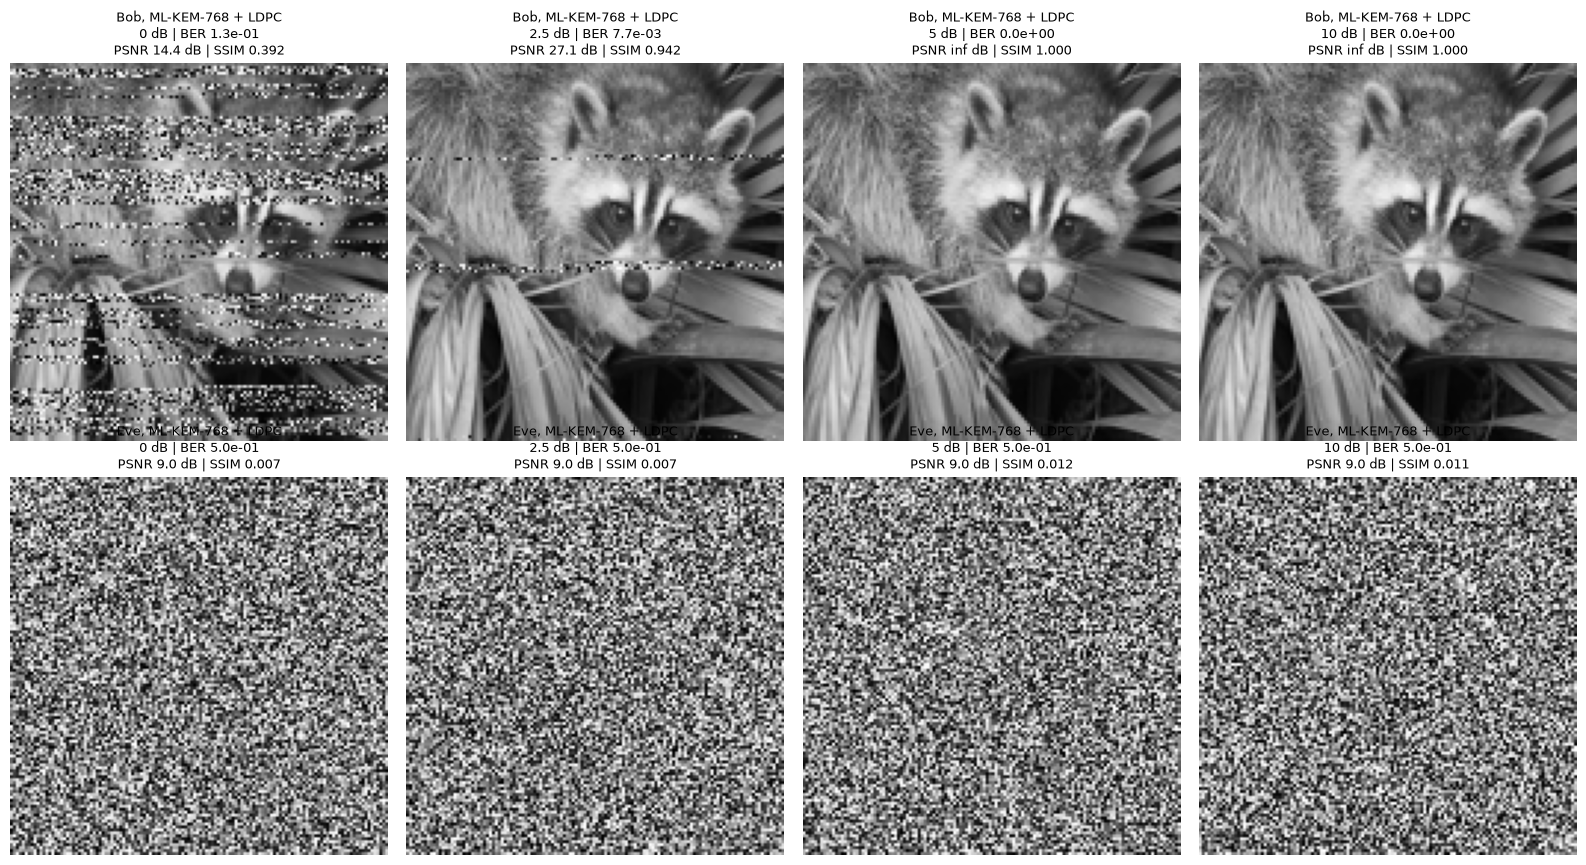

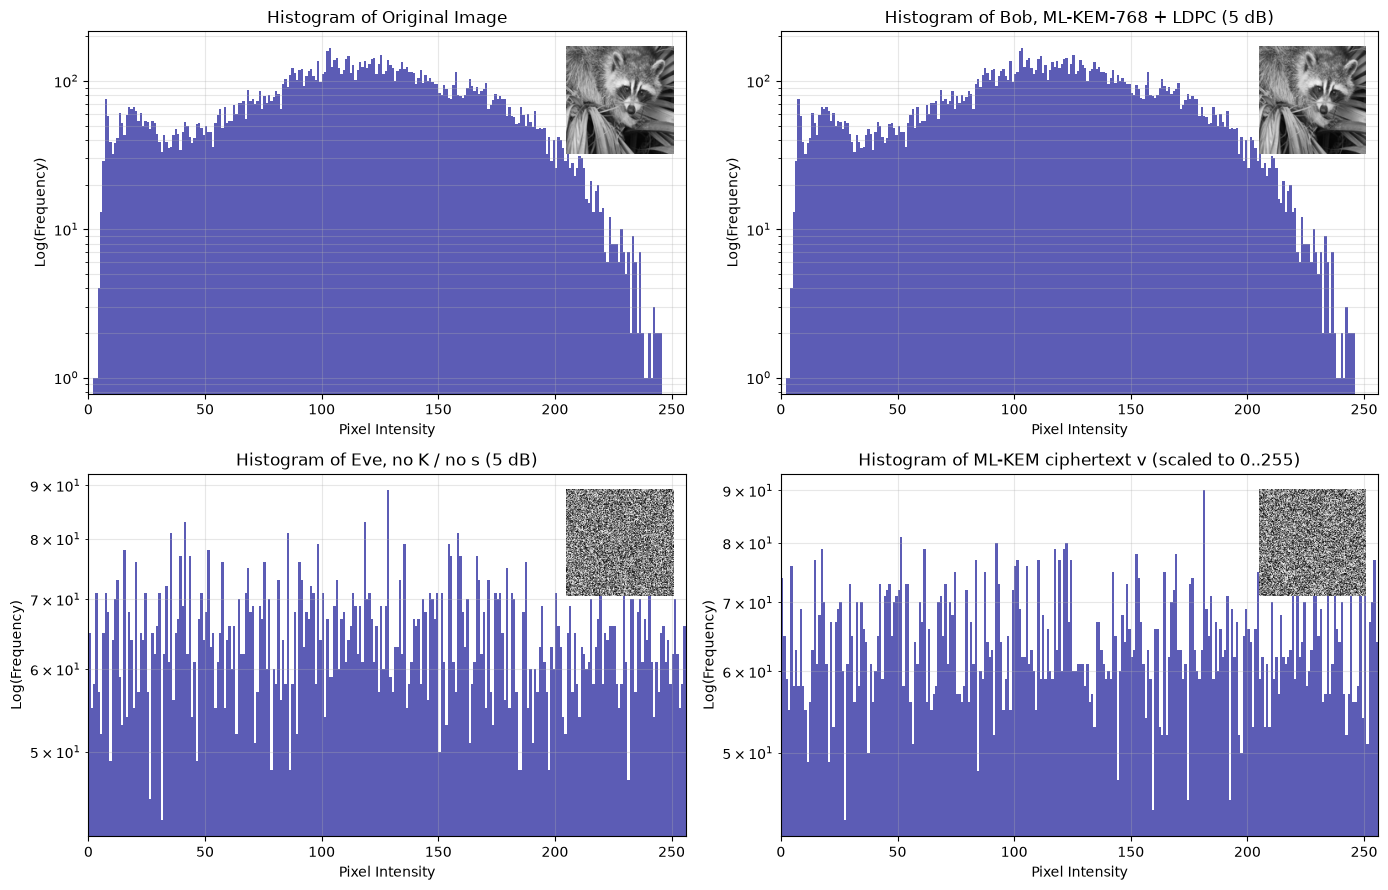

Image                                             Mean    Variance   Entropy
----------------------------------------------------------------------------
Original Image                                  113.48      2611.1     7.635
Bob, ML-KEM-768 + LDPC (5 dB)                   113.48      2611.1     7.635
Eve, no K / no s (5 dB)                         126.83      5382.0     7.989
ML-KEM ciphertext v (scaled to 0..255)          127.40      5447.7     7.989


In [41]:
PQC_IMG_EBNO = [0, 2.5, 5, 10]
# rebuild the test image and its bits here so this cell does not depend on global names
res = 128
img = np.array(Image.open(image_path).convert("L").resize((res, res)), dtype=np.uint8)
bits = np.unpackbits(img.flatten()).astype(np.float64)

m = PQCSubbandModel("umi", "ML-KEM-768", 32, 4, use_ldpc=True)
if torch.cuda.is_available(): m.cuda()
m._channel_model.allocate_topology_tensors(batch_size=16, num_bs=1, num_ut=m._num_ut)

fig, axes = plt.subplots(2, len(PQC_IMG_EBNO), figsize=(4 * len(PQC_IMG_EBNO), 8.6))
rx_imgs = {}
for r, (who, mode) in enumerate([("Bob", "secret_key"), ("Eve", "eve")]):
    m._mode = mode                                   # same keys and session; only the receiver changes
    for c, e in enumerate(PQC_IMG_EBNO):
        rx_bits = send_image_bits(m, bits, e)
        rx = np.packbits(rx_bits.astype(np.uint8)).reshape(res, res)
        rx_imgs[(who, e)] = rx
        ber_img = float(np.mean(rx_bits != bits))
        p = psnr(img, rx); s = ssim(img, rx, data_range=255) if ssim else float("nan")
        axes[r, c].imshow(rx, cmap="gray", vmin=0, vmax=255); axes[r, c].axis("off")
        axes[r, c].set_title(f"{who}, ML-KEM-768 + LDPC\n{e} dB | BER {ber_img:.1e}\nPSNR {p:.1f} dB | SSIM {s:.3f}", fontsize=9)
        print(f"{who:4s} Eb/No={e:>5} dB  BER={ber_img:.2e}  PSNR={p:6.2f} dB  SSIM={s:.4f}")
m._mode = "secret_key"
plt.tight_layout(); plt.show()

# --- ciphertext of the image (what goes over the air), mapped to 0..255 ---
with torch.no_grad():
    k, ntx = m._k, m._num_tx
    n_batch = int(np.ceil(res * res / (ntx * m._rg.num_data_symbols * 2)))    # enough coefficients
    b = torch.tensor(np.resize(bits, n_batch * ntx * k), dtype=torch.float64).reshape(n_batch, ntx, 1, k)
    if torch.cuda.is_available(): b = b.cuda()
    c_bits = m._encoder(b)[..., m._ilv.to(b.device)]
    _, _, _, v = m.encrypt_bits(c_bits)
cipher_pqc = np.floor(v.flatten().cpu().numpy()[:res * res] * 256 / m._pqc.q).astype(np.uint8).reshape(res, res)

E_HIST = 5
panels = [("Original Image", img), (f"Bob, ML-KEM-768 + LDPC ({E_HIST} dB)", rx_imgs[("Bob", E_HIST)]),
          (f"Eve, no K / no s ({E_HIST} dB)", rx_imgs[("Eve", E_HIST)]), ("ML-KEM ciphertext v (scaled to 0..255)", cipher_pqc)]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (title, im) in zip(axes.ravel(), panels):
    ax.hist(np.asarray(im).ravel(), bins=256, range=(0, 256), color="#3F3FA8", alpha=0.85)
    ax.set_yscale("log"); ax.set_xlim(0, 256)
    ax.set_title("Histogram of " + title, fontsize=12)
    ax.set_xlabel("Pixel Intensity"); ax.set_ylabel("Log(Frequency)")
    ax.grid(True, which="both", alpha=0.3)
    inset = ax.inset_axes([0.80, 0.66, 0.18, 0.30])
    inset.imshow(im, cmap="gray", vmin=0, vmax=255); inset.axis("off")
plt.tight_layout(); plt.show()

print(f"{'Image':44s}{'Mean':>10s}{'Variance':>12s}{'Entropy':>10s}")
print("-" * 76)
for title, im in panels:
    a = np.asarray(im, dtype=np.float64)
    print(f"{title:44s}{a.mean():10.2f}{a.var():12.1f}{entropy8(im):10.3f}")